# Gene-Set Pruning Triage, Refined

Presentation-ready robustness and sensitivity analysis for the old 34-program MDS MRD gene-set panel.

This notebook is derived from `old_geneset_pruning_metrics_20260430.ipynb`, but reorganizes the analysis flow:

1. Evaluate the full 34-gene-set model across DR methods and K values.
2. Separate malignant-vs-normal classification from latent-space structure preservation.
3. Choose sensible full-panel hyperparameter settings before interpreting pruning.
4. Inspect leave-one-program-out effects under matched method/K baselines.
5. Summarize pruning at both gene-set and broader biological-theme levels.

Scientific framing: this is a structured sensitivity analysis of a curated biological program panel, not a discovery claim that pruning identifies new MRD mechanisms. The conservative interpretation is that malignant MRD biology is distributed across inflammatory, stem-like, stress/quiescence, antigen-presentation, proliferation, and metabolic axes.

## 0. Setup

This notebook intentionally reuses the cached metric tables generated by the old pruning notebook / external pruning runner. It should not rerun dimensionality reduction unless those upstream outputs are missing.

In [1]:
from __future__ import annotations

import ast
import math
import re
import textwrap
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

SC_ROOT = Path("/home/minhang/mds_project/sc_classification")
EXP_DIR = SC_ROOT / "experiments" / "20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0"
OUT_DIR = EXP_DIR / "analysis" / "old_geneset_pruning_metrics"

METRICS_PATH = OUT_DIR / "panel_dr_metric_rows.csv"
LEADERBOARD_PATH = OUT_DIR / "panel_dr_leaderboard.csv"
PANEL_MANIFEST_PATH = OUT_DIR / "panel_manifest.csv"
PER_GENESET_HVG_PATH = OUT_DIR / "per_geneset_hvg_overlap.csv"
PATIENT_DELTA_PATH = OUT_DIR / "leave_one_geneset_patient_delta_auroc.csv"
MANIFEST_PATH = SC_ROOT / "scripts" / "knowledge_driven_embedding" / "older_geneset" / "manifest.tsv"

FIG_DIR = Path("figures/geneset_pruning_refined")
FIG_DIR.mkdir(parents=True, exist_ok=True)

PANEL_FULL = "full_34"
KNN_K = 30
RANK_EPS = 1e-12

for label, path in {
    "metrics table": METRICS_PATH,
    "leaderboard": LEADERBOARD_PATH,
    "panel manifest": PANEL_MANIFEST_PATH,
    "per-gene-set HVG overlap": PER_GENESET_HVG_PATH,
    "gene-set manifest": MANIFEST_PATH,
}.items():
    print(f"{label}: {path} exists={path.exists()}")

if not LEADERBOARD_PATH.exists():
    display(Markdown(
        f"**Missing required input:** `{LEADERBOARD_PATH}`. Copy or regenerate the old pruning outputs before running downstream cells."
    ))

print("Figures saved to:", FIG_DIR.resolve())

metrics table: /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/panel_dr_metric_rows.csv exists=True
leaderboard: /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/panel_dr_leaderboard.csv exists=True
panel manifest: /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/panel_manifest.csv exists=True
per-gene-set HVG overlap: /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/old_geneset_pruning_metrics/per_geneset_hvg_overlap.csv exists=True
gene-set manifest: /home/minhang/mds_project/sc_classification/scripts/knowledge_driven_embedding/older_geneset/manifest.tsv exists=True
Figures saved to: /home/minhang/mds_

## 1. Metric Definitions and Slide Formula

For each row $i=(\mathrm{panel}, \mathrm{method}, K)$, the dimensionality-reduction model produces a latent representation:

$$Z^{(i)} \in \mathbb{R}^{n \times K}.$$

Malignant-vs-normal classification is evaluated with patient-held-out `GroupKFold` logistic regression:

$$\hat{p}_a = \sigma(\beta_0 + \beta^\top z_a).$$

Across-patient AUROC:

$$\mathrm{AUROC}_{\mathrm{across}} = P(\hat{p}_+ > \hat{p}_-) + \frac{1}{2}P(\hat{p}_+ = \hat{p}_-).$$

Across-patient AUPRC:

$$\mathrm{AUPRC}_{\mathrm{across}} = \sum_r [\mathrm{Recall}(r)-\mathrm{Recall}(r-1)]\mathrm{Precision}(r).$$

Cell-type kNN macro purity uses each cell's local neighborhood:

$$q_a = \frac{1}{k}\sum_{b \in N_k(a)} \mathbf{1}(c_b=c_a),$$

$$\mathrm{kNN}_{\mathrm{celltype,macro}} = \frac{1}{|C|}\sum_{c \in C}\frac{1}{n_c}\sum_{a:c_a=c} q_a.$$

Pseudotime kNN smoothness compares neighbor pseudotime differences with random-pair differences:

$$\mathrm{kNN}_{\mathrm{pseudotime}} = 1 - \frac{D_{\mathrm{neighbor}}}{D_{\mathrm{random}} + \epsilon}.$$

Original composite score:

$$\mathrm{metric\_rank\_score}_i = \frac{1}{4}\left[R_{\mathrm{AUROC}}(i)+R_{\mathrm{AUPRC}}(i)+R_{\mathrm{celltype}}(i)+R_{\mathrm{pseudotime}}(i)\right],$$

$$\mathrm{triage\_score}_i = \mathrm{metric\_rank\_score}_i + 0.15 \times \mathrm{parsimony\_bonus}_i.$$

New decomposed scores:

$$\mathrm{malignancy\_rank\_score}_i = \frac{1}{2}\left[R_{\mathrm{AUROC}}(i)+R_{\mathrm{AUPRC}}(i)\right],$$

$$\mathrm{structure\_rank\_score}_i = \frac{1}{2}\left[R_{\mathrm{celltype}}(i)+R_{\mathrm{pseudotime}}(i)\right].$$

Matched full-panel delta:

$$\Delta \mathrm{score}_i = \mathrm{score}_i - \mathrm{score}_{\mathrm{full\_34},\ \mathrm{same\ method},K}.$$

Percentile ranks are used because AUROC, AUPRC, cell-type kNN purity, and pseudotime smoothness have different natural scales and dynamic ranges. The rank scores are relative multi-objective leaderboard metrics, not biological effect sizes.

In [2]:
def first_existing(df: pd.DataFrame, candidates: Iterable[str]) -> str | None:
    """Return the first available column name from a list of aliases."""
    for col in candidates:
        if col in df.columns:
            return col
    return None


def canonicalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Add stable column aliases while preserving the original old-notebook columns."""
    out = df.copy()

    aliases = {
        "panel": ["panel", "panel_id"],
        "K": ["K", "k", "n_components"],
        "across_mean_auroc": ["across_mean_auroc", "across_patient_auroc"],
        "across_mean_auprc": ["across_mean_auprc", "across_patient_auprc"],
        "within_mean_auroc": ["within_mean_auroc", "within_patient_mean_auroc"],
        "celltype_knn_purity_macro": ["celltype_knn_purity_macro", "knn_label_purity_macro"],
        "pseudotime_knn_smoothness": ["pseudotime_knn_smoothness"],
    }

    for canonical, candidates in aliases.items():
        found = first_existing(out, candidates)
        if found is not None and canonical not in out.columns:
            out[canonical] = out[found]

    if "K" in out.columns:
        out["K"] = pd.to_numeric(out["K"], errors="coerce").astype("Int64")

    if "panel" in out.columns and "dropped_geneset" not in out.columns:
        out["dropped_geneset"] = out.apply(infer_dropped_geneset, axis=1)

    return out


def parse_listish(value) -> list[str]:
    """Parse old CSV list strings like "['HALLMARK_X']" into Python lists."""
    if isinstance(value, list):
        return [str(v) for v in value]
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, set)):
            return [str(v) for v in parsed]
    except (SyntaxError, ValueError):
        pass
    return [text]


def infer_dropped_geneset(row: pd.Series) -> str | None:
    excluded = parse_listish(row.get("excluded_gene_sets", None))
    if len(excluded) == 1:
        return excluded[0]
    if len(excluded) > 1:
        return " + ".join(excluded)

    panel = str(row.get("panel", row.get("panel_id", "")))
    prefix = "drop_geneset__"
    if panel.startswith(prefix):
        return panel[len(prefix):].upper()
    return None


def add_rank_scores(
    df: pd.DataFrame,
    auroc_col: str = "across_mean_auroc",
    auprc_col: str = "across_mean_auprc",
    celltype_col: str = "celltype_knn_purity_macro",
    pseudotime_col: str = "pseudotime_knn_smoothness",
    parsimony_col: str = "parsimony_bonus",
) -> pd.DataFrame:
    """Add decomposed percentile-rank scores using successful rows only."""
    out = df.copy()
    ok_mask = out["status"].eq("ok") if "status" in out.columns else pd.Series(True, index=out.index)

    metric_cols = {
        "across_auroc": auroc_col,
        "across_auprc": auprc_col,
        "celltype_knn_purity_macro": celltype_col,
        "pseudotime_knn_smoothness": pseudotime_col,
    }

    for rank_name, col in metric_cols.items():
        if col not in out.columns:
            raise KeyError(f"Missing metric column: {col}")
        out[f"rank_{rank_name}"] = np.nan
        out.loc[ok_mask, f"rank_{rank_name}"] = out.loc[ok_mask, col].rank(
            pct=True, method="average", na_option="bottom"
        )

    # Short aliases make some plotting code easier to scan.
    out["rank_auroc"] = out["rank_across_auroc"]
    out["rank_auprc"] = out["rank_across_auprc"]
    out["rank_celltype"] = out["rank_celltype_knn_purity_macro"]
    out["rank_pseudotime"] = out["rank_pseudotime_knn_smoothness"]

    out["malignancy_rank_score"] = out[["rank_across_auroc", "rank_across_auprc"]].mean(axis=1)
    out["structure_rank_score"] = out[["rank_celltype_knn_purity_macro", "rank_pseudotime_knn_smoothness"]].mean(axis=1)
    out["metric_rank_score_refined"] = out[
        ["rank_across_auroc", "rank_across_auprc", "rank_celltype_knn_purity_macro", "rank_pseudotime_knn_smoothness"]
    ].mean(axis=1)

    if parsimony_col in out.columns:
        out["triage_score_refined"] = out["metric_rank_score_refined"] + 0.15 * out[parsimony_col].fillna(0)
    else:
        out["triage_score_refined"] = out["metric_rank_score_refined"]

    return out


def compute_matched_full_deltas(
    df: pd.DataFrame,
    full_panel: str = PANEL_FULL,
    key_cols: list[str] | None = None,
    score_cols: list[str] | None = None,
) -> pd.DataFrame:
    """Compare every row with the full_34 row using the same DR method and K."""
    key_cols = key_cols or ["method", "K"]
    score_cols = score_cols or [
        "across_mean_auroc",
        "across_mean_auprc",
        "celltype_knn_purity_macro",
        "pseudotime_knn_smoothness",
        "malignancy_rank_score",
        "structure_rank_score",
        "metric_rank_score_refined",
        "triage_score_refined",
    ]

    full_ref = df.loc[df["panel"].eq(full_panel), key_cols + score_cols].copy()
    full_ref = full_ref.rename(columns={col: f"full_{col}" for col in score_cols})
    merged = df.merge(full_ref, on=key_cols, how="left", validate="many_to_one")

    for col in score_cols:
        merged[f"delta_{col}"] = merged[col] - merged[f"full_{col}"]

    # Backward-compatible names used by the old notebook and requested plots.
    rename_delta = {
        "delta_metric_rank_score_refined": "delta_metric_rank_score",
        "delta_triage_score_refined": "delta_triage_score",
    }
    for old, new in rename_delta.items():
        if old in merged.columns and new not in merged.columns:
            merged[new] = merged[old]

    return merged


def save_figure(fig: plt.Figure, stem: str, dpi: int = 300) -> tuple[Path, Path]:
    """Save a figure as PNG and PDF with tight layout."""
    png = FIG_DIR / f"{stem}.png"
    pdf = FIG_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print(f"Saved {png}")
    print(f"Saved {pdf}")
    return png, pdf


def plot_method_k_heatmap(
    data: pd.DataFrame,
    value_col: str,
    title: str,
    filename: str,
    cmap: str = "viridis",
    center: float | None = None,
) -> plt.Figure:
    pivot = data.pivot_table(index="method", columns="K", values=value_col, aggfunc="mean")
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, center=center, linewidths=0.5, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("K")
    ax.set_ylabel("DR method")
    save_figure(fig, filename)
    plt.show()
    return fig


def label_extreme_points(
    ax: plt.Axes,
    df: pd.DataFrame,
    x: str,
    y: str,
    label: str,
    n: int = 8,
) -> None:
    if df.empty:
        return
    tmp = df[[x, y, label]].dropna().copy()
    if tmp.empty:
        return
    tmp["extremeness"] = tmp[x].abs().rank(pct=True) + tmp[y].abs().rank(pct=True)
    for _, row in tmp.nlargest(min(n, len(tmp)), "extremeness").iterrows():
        ax.text(row[x], row[y], str(row[label]), fontsize=8, ha="left", va="bottom")


def make_theme_palette(themes: Iterable[str]) -> dict[str, tuple[float, float, float]]:
    themes = sorted(pd.Series(list(themes)).dropna().unique())
    colors = sns.color_palette("tab20", n_colors=max(len(themes), 1))
    return dict(zip(themes, colors))


def split_gene_list(value) -> set[str]:
    """Parse semicolon-delimited gene lists from saved overlap tables."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return set()
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return set()
    return {g.strip() for g in text.split(";") if g.strip()}


def make_geneset_count_table(overlap_df: pd.DataFrame) -> pd.DataFrame:
    """Create per-gene-set labels with total covered genes and HVG overlap."""
    if overlap_df.empty:
        return pd.DataFrame(columns=[
            "dropped_geneset", "geneset_n_genes", "geneset_n_hvg_genes", "geneset_hvg_fraction", "gene_count_suffix"
        ])

    required = {"geneset_name", "covered_n_genes", "overlap_hvg_n_genes"}
    missing = required - set(overlap_df.columns)
    if missing:
        raise KeyError(f"Missing overlap columns: {sorted(missing)}")

    out = overlap_df[["geneset_name", "covered_n_genes", "overlap_hvg_n_genes"]].copy()
    out = out.rename(columns={
        "geneset_name": "dropped_geneset",
        "covered_n_genes": "geneset_n_genes",
        "overlap_hvg_n_genes": "geneset_n_hvg_genes",
    })
    out["geneset_n_genes"] = pd.to_numeric(out["geneset_n_genes"], errors="coerce").astype("Int64")
    out["geneset_n_hvg_genes"] = pd.to_numeric(out["geneset_n_hvg_genes"], errors="coerce").astype("Int64")
    out["geneset_hvg_fraction"] = out["geneset_n_hvg_genes"] / out["geneset_n_genes"]
    out["gene_count_suffix"] = out.apply(
        lambda r: f"n={int(r['geneset_n_genes'])}; HVG={int(r['geneset_n_hvg_genes'])}/{int(r['geneset_n_genes'])} ({r['geneset_hvg_fraction']:.0%})"
        if pd.notna(r["geneset_n_genes"]) and int(r["geneset_n_genes"]) > 0 and pd.notna(r["geneset_n_hvg_genes"])
        else "n=NA; HVG=NA",
        axis=1,
    )
    return out


def make_theme_count_table(overlap_df: pd.DataFrame, theme_map: dict[str, str]) -> pd.DataFrame:
    """Aggregate unique covered/HVG genes across gene sets within each biological theme."""
    if overlap_df.empty:
        return pd.DataFrame(columns=["theme", "theme_n_genes", "theme_n_hvg_genes", "theme_hvg_fraction", "theme_count_suffix"])

    rows = []
    for theme in sorted(set(theme_map.values())):
        genes: set[str] = set()
        hvg_genes: set[str] = set()
        member_names = {gs for gs, mapped_theme in theme_map.items() if mapped_theme == theme}
        sub = overlap_df.loc[overlap_df["geneset_name"].isin(member_names)].copy()
        for _, row in sub.iterrows():
            hvg = split_gene_list(row.get("overlap_hvg_genes"))
            old_only = split_gene_list(row.get("covered_only_old_genes"))
            hvg_genes |= hvg
            genes |= hvg | old_only
        n_genes = len(genes)
        n_hvg = len(hvg_genes)
        frac = n_hvg / n_genes if n_genes else np.nan
        rows.append({
            "theme": theme,
            "theme_n_genes": n_genes,
            "theme_n_hvg_genes": n_hvg,
            "theme_hvg_fraction": frac,
            "theme_count_suffix": f"n={n_genes}; HVG={n_hvg}/{n_genes} ({frac:.0%})" if n_genes else "n=NA; HVG=NA",
        })
    return pd.DataFrame(rows)


def append_count_suffix(name: str, suffix: str | float | None, width: int = 42) -> str:
    """Wrap long names and append gene/HVG counts in parentheses."""
    wrapped = textwrap.fill(str(name), width=width)
    if suffix is None or (isinstance(suffix, float) and np.isnan(suffix)):
        return wrapped
    return f"{wrapped}\n({suffix})"


def add_geneset_count_labels(frame: pd.DataFrame, count_table: pd.DataFrame) -> pd.DataFrame:
    out = frame.merge(count_table, on="dropped_geneset", how="left")
    out["dropped_geneset_label"] = out.apply(
        lambda r: append_count_suffix(r["dropped_geneset"], r.get("gene_count_suffix"), width=44),
        axis=1,
    )
    return out


def add_theme_count_labels(frame: pd.DataFrame, theme_count_table: pd.DataFrame) -> pd.DataFrame:
    out = frame.merge(theme_count_table, on="theme", how="left")
    out["theme_label"] = out.apply(
        lambda r: append_count_suffix(r["theme"], r.get("theme_count_suffix"), width=34),
        axis=1,
    )
    return out

In [3]:
metrics_df = pd.read_csv(METRICS_PATH) if METRICS_PATH.exists() else pd.DataFrame()
leaderboard_raw = pd.read_csv(LEADERBOARD_PATH)
panel_manifest = pd.read_csv(PANEL_MANIFEST_PATH) if PANEL_MANIFEST_PATH.exists() else pd.DataFrame()
per_geneset_hvg_overlap = pd.read_csv(PER_GENESET_HVG_PATH) if PER_GENESET_HVG_PATH.exists() else pd.DataFrame()
geneset_manifest = pd.read_csv(MANIFEST_PATH, sep="\t") if MANIFEST_PATH.exists() else pd.DataFrame()

leaderboard_raw = canonicalize_columns(leaderboard_raw)
metrics_df = canonicalize_columns(metrics_df) if not metrics_df.empty else metrics_df

required_cols = [
    "panel",
    "panel_type",
    "method",
    "K",
    "status",
    "across_mean_auroc",
    "across_mean_auprc",
    "celltype_knn_purity_macro",
    "pseudotime_knn_smoothness",
]
missing = [c for c in required_cols if c not in leaderboard_raw.columns]
assert not missing, missing

print("leaderboard shape:", leaderboard_raw.shape)
print("leaderboard columns:")
print(list(leaderboard_raw.columns))
display(leaderboard_raw.head())

print("\nmetrics table shape:", metrics_df.shape)
if not metrics_df.empty:
    display(metrics_df.head())

print("\npanel manifest shape:", panel_manifest.shape)
display(panel_manifest.head())

print("\nper-gene-set HVG overlap shape:", per_geneset_hvg_overlap.shape)
display(per_geneset_hvg_overlap.head())

leaderboard shape: (396, 59)
leaderboard columns:
['panel_id', 'panel_type', 'method', 'k', 'seed', 'description', 'n_gene_sets', 'n_genes', 'score_source', 'reused_existing_plan0', 'status', 'n_cells', 'n_components', 'knn_label_purity_micro', 'knn_label_purity_macro', 'celltype_silhouette', 'celltype_probe_balanced_accuracy', 'celltype_probe_macro_f1', 'pseudotime_knn_absdiff', 'pseudotime_knn_smoothness', 'pseudotime_distance_spearman', 'across_patient_auroc', 'across_patient_auprc', 'across_patient_brier', 'across_patient_log_loss', 'across_patient_n_folds', 'within_patient_mean_auroc', 'within_patient_mean_auprc', 'within_patient_mean_brier', 'within_patient_mean_log_loss', 'within_patient_n_patients', 'n_excluded_genes', 'n_shared_genes_removed', 'excluded_gene_sets', 'excluded_genes', 'genes', 'extras_keys', 'baseline_across_patient_auroc', 'baseline_across_patient_auprc', 'baseline_knn_label_purity_macro', 'baseline_pseudotime_knn_smoothness', 'baseline_n_genes', 'baseline_n_ge

,panel_id,panel_type,method,k,seed,description,n_gene_sets,n_genes,score_source,reused_existing_plan0,...,metric_rank_score,parsimony_bonus,triage_score,panel,K,across_mean_auroc,across_mean_auprc,within_mean_auroc,celltype_knn_purity_macro,dropped_geneset
0,drop_geneset__reactome_mhc_class_i_antigen_pre...,leave_one_geneset_out_strict_gene_ablation,pca,40,1,Full panel minus geneset: REACTOME_MHC_CLASS_I...,33,2864,/home/minhang/mds_project/sc_classification/ex...,False,...,0.828914,0.114135,0.846034,drop_geneset__reactome_mhc_class_i_antigen_pre...,40,0.858751,0.313885,0.912252,0.784311,REACTOME_MHC_CLASS_I_ANTIGEN_PRESENTATION
1,drop_geneset__hallmark_g2m_checkpoint,leave_one_geneset_out_strict_gene_ablation,pca,40,1,Full panel minus geneset: HALLMARK_G2M_CHECKPO...,33,3040,/home/minhang/mds_project/sc_classification/ex...,False,...,0.836490,0.059697,0.845444,drop_geneset__hallmark_g2m_checkpoint,40,0.856121,0.313803,0.912643,0.785315,HALLMARK_G2M_CHECKPOINT
2,drop_geneset__reactome_interferon_signaling,leave_one_geneset_out_strict_gene_ablation,pca,40,1,Full panel minus geneset: REACTOME_INTERFERON_...,33,2959,/home/minhang/mds_project/sc_classification/ex...,False,...,0.809343,0.084751,0.822056,drop_geneset__reactome_interferon_signaling,40,0.855809,0.286908,0.914638,0.786544,REACTOME_INTERFERON_SIGNALING
3,drop_geneset__hallmark_dna_repair,leave_one_geneset_out_strict_gene_ablation,pca,40,1,Full panel minus geneset: HALLMARK_DNA_REPAIR;...,33,3084,/home/minhang/mds_project/sc_classification/ex...,False,...,0.808081,0.046087,0.814994,drop_geneset__hallmark_dna_repair,40,0.853833,0.307015,0.914472,0.785166,HALLMARK_DNA_REPAIR
4,drop_geneset__hallmark_e2f_targets,leave_one_geneset_out_strict_gene_ablation,pca,40,1,Full panel minus geneset: HALLMARK_E2F_TARGETS...,33,3035,/home/minhang/mds_project/sc_classification/ex...,False,...,0.804924,0.061243,0.814111,drop_geneset__hallmark_e2f_targets,40,0.852743,0.293798,0.913299,0.786987,HALLMARK_E2F_TARGETS



metrics table shape: (396, 44)


,panel_id,panel_type,method,k,seed,description,n_gene_sets,n_genes,score_source,reused_existing_plan0,...,excluded_genes,genes,extras_keys,panel,K,across_mean_auroc,across_mean_auprc,within_mean_auroc,celltype_knn_purity_macro,dropped_geneset
0,full_34,full_control,fa,20,1,Full 34-gene-set union control.,34,3233,/home/minhang/mds_project/sc_classification/ex...,True,...,NaN,NaN,NaN,full_34,20,0.869707,0.167019,0.898410,0.763725,None
1,full_34,full_control,fa,40,1,Full 34-gene-set union control.,34,3233,/home/minhang/mds_project/sc_classification/ex...,True,...,NaN,NaN,NaN,full_34,40,0.859415,0.252153,0.922330,0.782741,None
2,full_34,full_control,fa,60,1,Full 34-gene-set union control.,34,3233,/home/minhang/mds_project/sc_classification/ex...,True,...,NaN,NaN,NaN,full_34,60,0.839044,0.319460,0.932728,0.773887,None
3,full_34,full_control,factosig,20,1,Full 34-gene-set union control.,34,3233,/home/minhang/mds_project/sc_classification/ex...,True,...,NaN,NaN,NaN,full_34,20,0.870078,0.167110,0.896504,0.769057,None
4,full_34,full_control,factosig,40,1,Full 34-gene-set union control.,34,3233,/home/minhang/mds_project/sc_classification/ex...,True,...,NaN,NaN,NaN,full_34,40,0.858918,0.231462,0.918079,0.784896,None



panel manifest shape: (44, 11)


,panel_id,panel_type,description,n_gene_sets,n_genes,n_excluded_genes,n_shared_genes_removed,genesets,excluded_gene_sets,excluded_genes,genes
0,core_only,core_only,Manifest-priority Core genesets only.,19,1888,0,0,HALLMARK_INTERFERON_GAMMA_RESPONSE;HALLMARK_IN...,NaN,NaN,A2M;AAAS;ABAT;ABCA1;ABCB7;ABCC5;ABCE1;ABHD4;AB...
1,full_34,full_control,Full 34-gene-set union control.,34,3233,0,0,HALLMARK_INTERFERON_GAMMA_RESPONSE;HALLMARK_IN...,NaN,NaN,A2M;AAAS;ABAT;ABCA1;ABCB1;ABCB6;ABCB7;ABCC1;AB...
2,drop_group__antigen_presentation,group_dropout_strict_gene_ablation,Full panel minus biology group: antigen_presen...,30,2719,514,217,HALLMARK_INTERFERON_GAMMA_RESPONSE;HALLMARK_IN...,KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION;REACT...,ACTR10;ACTR1A;ACTR1B;ADRM1;ANAPC1;ANAPC10;ANAP...,A2M;AAAS;ABAT;ABCA1;ABCB1;ABCB6;ABCB7;ABCC1;AB...
3,drop_group__cytokine_jak_stat,group_dropout_strict_gene_ablation,Full panel minus biology group: cytokine_jak_s...,30,2281,952,617,HALLMARK_INTERFERON_GAMMA_RESPONSE;HALLMARK_IN...,HALLMARK_IL2_STAT5_SIGNALING;HALLMARK_IL6_JAK_...,A2M;AAAS;ABCB1;ABCE1;ABL2;ACTB;ACTG1;ACVR1B;AC...,ABAT;ABCA1;ABCB6;ABCB7;ABCC1;ABCC5;ABCF2;ABHD4...
4,drop_group__inflammatory_interferon,group_dropout_strict_gene_ablation,Full panel minus biology group: inflammatory_i...,26,2500,733,540,HALLMARK_IL6_JAK_STAT3_SIGNALING;HALLMARK_IL2_...,HALLMARK_INFLAMMATORY_RESPONSE;HALLMARK_INTERF...,AAAS;ABCA1;ABCE1;ABI1;ACKR3;ACTB;ACTG1;ACVR1B;...,A2M;ABAT;ABCB1;ABCB6;ABCB7;ABCC1;ABCC5;ABCF2;A...



per-gene-set HVG overlap shape: (34, 11)


,geneset_name,covered_n_genes,overlap_hvg_n_genes,covered_fraction_in_hvg,covered_only_old_n_genes,overlap_hvg_genes,covered_only_old_genes,source,why_include,priority,biology_group
0,REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMBLY...,29,2,0.068966,27,CALR;HSPA5,ATG14;B2M;BCAP31;BECN1;CANX;ERAP1;ERAP2;HLA-A;...,Reactome,Antigen presentation (Reactome/KEGG): required...,Core,antigen_presentation
1,REACTOME_TNFR1_INDUCED_NFKB_SIGNALING_PATHWAY,33,8,0.242424,25,BIRC3;OPTN;OTUD1;OTUD7B;TNF;TNFAIP3;TRAF1;UBB,BIRC2;CHUK;CYLD;IKBKB;IKBKG;MAP3K7;RACK1;RBCK1...,Reactome,IFNg/IFNa/TNF/NFkB/inflammation: core immune-p...,Optional,inflammatory_interferon
2,REACTOME_MHC_CLASS_I_ANTIGEN_PRESENTATION,369,92,0.249322,277,ASB18;ASB5;ASB7;CALR;CBLL2;CCNF;CD14;CD36;CDC2...,ADRM1;ANAPC1;ANAPC10;ANAPC11;ANAPC13;ANAPC2;AN...,Reactome,Antigen presentation (Reactome/KEGG): required...,Optional,antigen_presentation
3,HALLMARK_OXIDATIVE_PHOSPHORYLATION,200,59,0.295000,141,ACAA2;ACADSB;ACAT1;ATP1B1;ATP5F1A;ATP5F1B;ATP5...,ABCB7;ACAA1;ACADM;ACADVL;ACO2;AFG3L2;AIFM1;ALA...,H,E2F/G2M/MYC/OXPHOS/glycolysis/mTORC1: prolifer...,Core,proliferation_metabolism
4,HALLMARK_DNA_REPAIR,149,51,0.342282,98,ADA;ADCY6;AK1;ALYREF;APRT;ARL6IP1;CCNO;CDA;CMP...,AAAS;ADRM1;AGO4;AK3;BCAM;BCAP31;BOLA2;BRF2;CAN...,H,p53/apoptosis/hypoxia/UPR/ROS/DNA repair: stre...,Optional,stress_arrest


## 2. Add Refined Scoring Columns

The old `triage_score` is preserved. The new columns decompose the same four metric ranks into malignant-vs-normal generalization and cell-type / pseudotime structure preservation.

In [4]:
df = add_rank_scores(leaderboard_raw)

compare_cols = [
    ("metric_rank_score", "metric_rank_score_refined"),
    ("triage_score", "triage_score_refined"),
]
for old_col, new_col in compare_cols:
    if old_col in df.columns and new_col in df.columns:
        diff = (df[old_col] - df[new_col]).abs()
        print(f"max |{old_col} - {new_col}|:", diff.max())
        if diff.max(skipna=True) > 1e-9:
            print(
                "  Difference detected. Check whether the old notebook used a different row subset, "
                "missing-value policy, or metric column alias."
            )

score_cols_to_show = [
    "panel", "panel_type", "method", "K",
    "across_mean_auroc", "across_mean_auprc",
    "celltype_knn_purity_macro", "pseudotime_knn_smoothness",
    "rank_across_auroc", "rank_across_auprc",
    "rank_celltype_knn_purity_macro", "rank_pseudotime_knn_smoothness",
    "malignancy_rank_score", "structure_rank_score",
    "metric_rank_score_refined", "triage_score_refined",
]
score_cols_to_show = [c for c in score_cols_to_show if c in df.columns]
print("scored dataframe shape:", df.shape)
display(df[score_cols_to_show].head(10))

max |metric_rank_score - metric_rank_score_refined|: 8.326672684688674e-17
max |triage_score - triage_score_refined|: 1.1102230246251565e-16
scored dataframe shape: (396, 71)


,panel,panel_type,method,K,across_mean_auroc,across_mean_auprc,celltype_knn_purity_macro,pseudotime_knn_smoothness,rank_across_auroc,rank_across_auprc,rank_celltype_knn_purity_macro,rank_pseudotime_knn_smoothness,malignancy_rank_score,structure_rank_score,metric_rank_score_refined,triage_score_refined
0,drop_geneset__reactome_mhc_class_i_antigen_pre...,leave_one_geneset_out_strict_gene_ablation,pca,40,0.858751,0.313885,0.784311,0.798206,0.595960,0.891414,0.898990,0.929293,0.743687,0.914141,0.828914,0.846034
1,drop_geneset__hallmark_g2m_checkpoint,leave_one_geneset_out_strict_gene_ablation,pca,40,0.856121,0.313803,0.785315,0.799952,0.505051,0.888889,0.959596,0.992424,0.696970,0.976010,0.836490,0.845444
2,drop_geneset__reactome_interferon_signaling,leave_one_geneset_out_strict_gene_ablation,pca,40,0.855809,0.286908,0.786544,0.799135,0.492424,0.780303,0.994949,0.969697,0.636364,0.982323,0.809343,0.822056
3,drop_geneset__hallmark_dna_repair,leave_one_geneset_out_strict_gene_ablation,pca,40,0.853833,0.307015,0.785166,0.799425,0.446970,0.856061,0.944444,0.984848,0.651515,0.964646,0.808081,0.814994
4,drop_geneset__hallmark_e2f_targets,leave_one_geneset_out_strict_gene_ablation,pca,40,0.852743,0.293798,0.786987,0.800768,0.414141,0.808081,0.997475,1.000000,0.611111,0.998737,0.804924,0.814111
5,drop_group__tgf_plasticity,group_dropout_strict_gene_ablation,pca,40,0.864219,0.381636,0.780899,0.796507,0.712121,0.994949,0.679293,0.820707,0.853535,0.750000,0.801768,0.813181
6,drop_geneset__hallmark_tgf_beta_signaling,leave_one_geneset_out_strict_gene_ablation,pca,40,0.857585,0.285457,0.784304,0.798975,0.560606,0.770202,0.896465,0.964646,0.665404,0.930556,0.797980,0.800485
7,redundancy_pruned_jaccard50,redundancy_pruned,pca,60,0.860255,0.293155,0.782861,0.798084,0.636364,0.805556,0.809343,0.925505,0.720960,0.867424,0.794192,0.794192
8,full_34,full_control,pca,60,0.860255,0.293155,0.782861,0.798084,0.633838,0.803030,0.809343,0.925505,0.718434,0.867424,0.792929,0.792929
9,drop_geneset__hallmark_tnfa_signaling_via_nfkb,leave_one_geneset_out_strict_gene_ablation,pca,60,0.864402,0.325776,0.781163,0.796063,0.717172,0.926768,0.689394,0.797980,0.821970,0.743687,0.782828,0.792061


## 3. Full 34-Gene-Set Baseline First

Before interpreting any pruning result, evaluate the full curated panel across DR methods and K. This separates model-selection behavior from downstream ablation behavior.

Saved figures/geneset_pruning_refined/01_full34_triage_heatmap.png
Saved figures/geneset_pruning_refined/01_full34_triage_heatmap.pdf


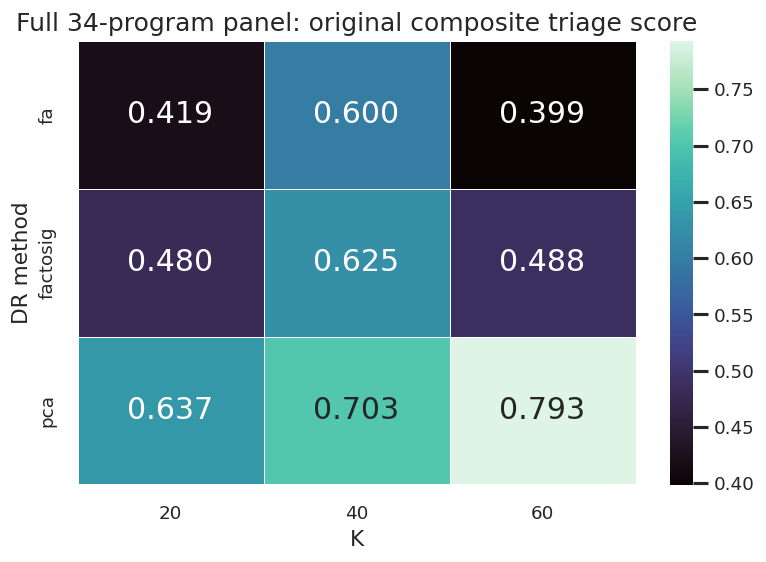

full_34 rows: 9


,panel,method,K,triage_score,malignancy_rank_score,structure_rank_score
8,full_34,pca,60,0.792929,0.718434,0.867424
42,full_34,pca,40,0.703283,0.459596,0.946970
89,full_34,pca,20,0.636679,0.632576,0.640783
99,full_34,factosig,40,0.625000,0.546717,0.703283
124,full_34,fa,40,0.599747,0.601010,0.598485
220,full_34,factosig,60,0.488005,0.539141,0.436869
224,full_34,factosig,20,0.480429,0.512626,0.448232
282,full_34,fa,20,0.419192,0.502525,0.335859
300,full_34,fa,60,0.398990,0.526515,0.271465


In [5]:
full = df.loc[df["panel"].eq(PANEL_FULL) & df["status"].eq("ok")].copy()
assert not full.empty, "No successful full_34 rows found."

triage_col_for_plot = "triage_score" if "triage_score" in full.columns else "triage_score_refined"
plot_method_k_heatmap(
    full,
    value_col=triage_col_for_plot,
    title="Full 34-program panel: original composite triage score",
    filename="01_full34_triage_heatmap",
    cmap="mako",
)

print("full_34 rows:", full.shape[0])
display(full[["panel", "method", "K", triage_col_for_plot, "malignancy_rank_score", "structure_rank_score"]].sort_values(triage_col_for_plot, ascending=False))

Saved figures/geneset_pruning_refined/02_full34_malignancy_structure_heatmaps.png
Saved figures/geneset_pruning_refined/02_full34_malignancy_structure_heatmaps.pdf


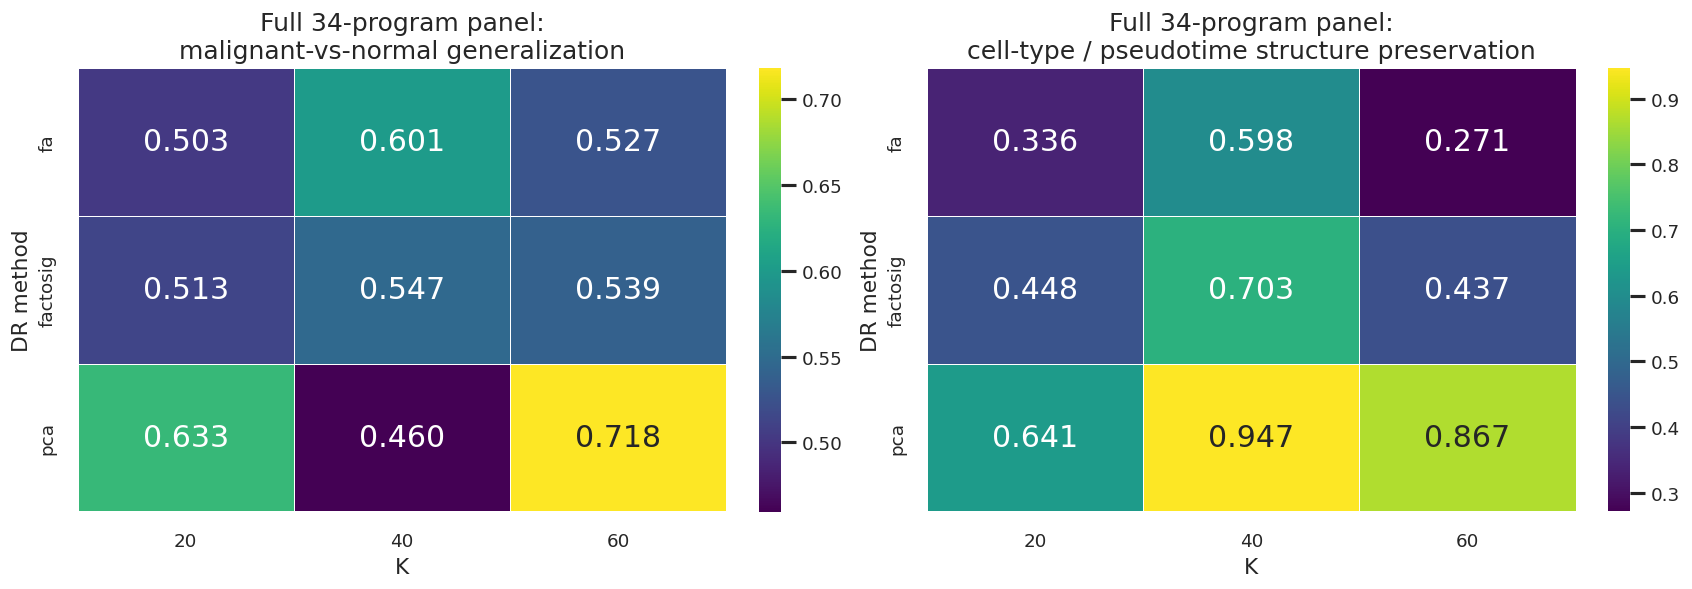

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
for ax, value_col, title in [
    (axes[0], "malignancy_rank_score", "Full 34-program panel:\nmalignant-vs-normal generalization"),
    (axes[1], "structure_rank_score", "Full 34-program panel:\ncell-type / pseudotime structure preservation"),
]:
    pivot = full.pivot_table(index="method", columns="K", values=value_col, aggfunc="mean")
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", linewidths=0.5, ax=ax)
    ax.set_xlabel("K")
    ax.set_ylabel("DR method")
    ax.set_title(title)

save_figure(fig, "02_full34_malignancy_structure_heatmaps")
plt.show()

Saved figures/geneset_pruning_refined/02_full34_malignancy_structure_heatmaps_same_color_range.png
Saved figures/geneset_pruning_refined/02_full34_malignancy_structure_heatmaps_same_color_range.pdf


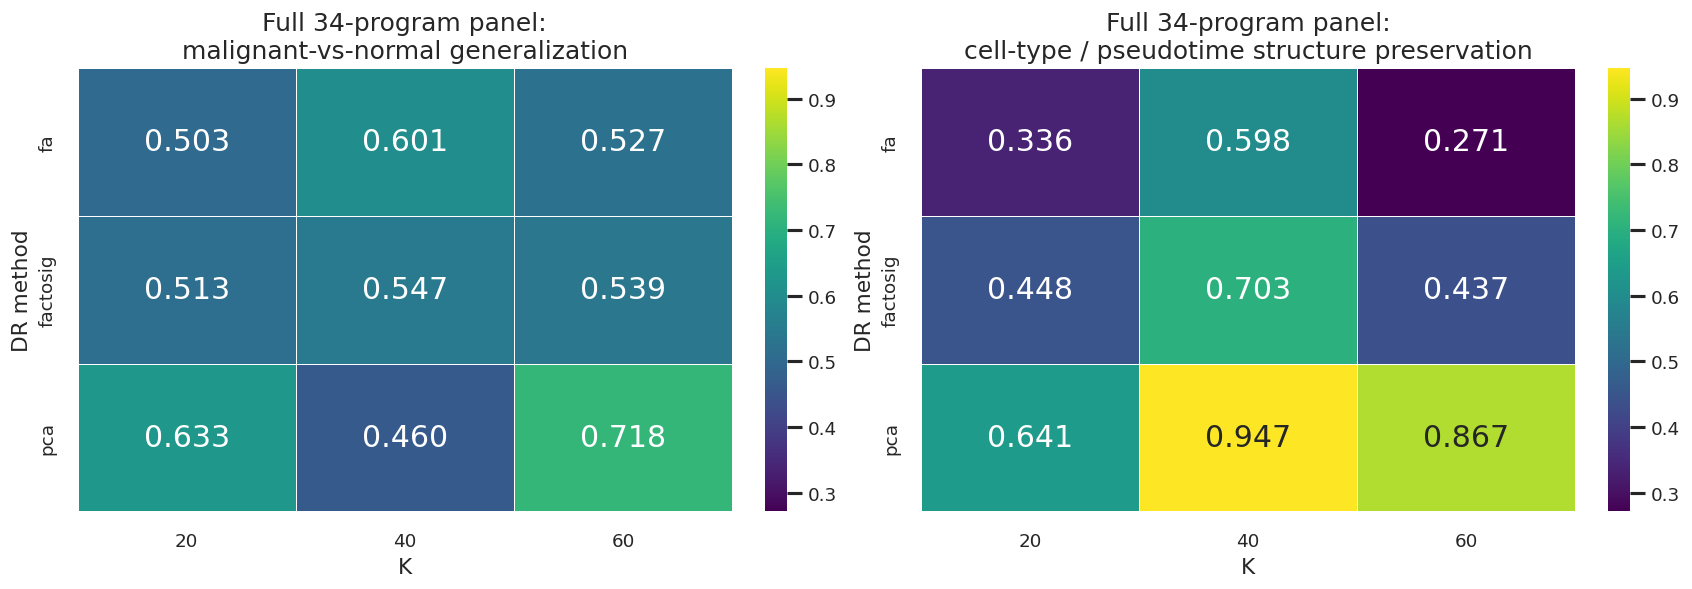

In [7]:
heatmap_specs = [
    ("malignancy_rank_score", "Full 34-program panel:\nmalignant-vs-normal generalization"),
    ("structure_rank_score", "Full 34-program panel:\ncell-type / pseudotime structure preservation"),
]

pivots = [
    full.pivot_table(index="method", columns="K", values=value_col, aggfunc="mean")
    for value_col, _ in heatmap_specs
]

shared_vmin = min(pivot.min().min() for pivot in pivots)
shared_vmax = max(pivot.max().max() for pivot in pivots)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)

for ax, pivot, (_, title) in zip(axes, pivots, heatmap_specs):
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        linewidths=0.5,
        vmin=shared_vmin,
        vmax=shared_vmax,
        ax=ax,
    )
    ax.set_xlabel("K")
    ax.set_ylabel("DR method")
    ax.set_title(title)

save_figure(fig, "02_full34_malignancy_structure_heatmaps_same_color_range")
plt.show()

Saved figures/geneset_pruning_refined/03_full34_malignancy_structure_scatter.png
Saved figures/geneset_pruning_refined/03_full34_malignancy_structure_scatter.pdf


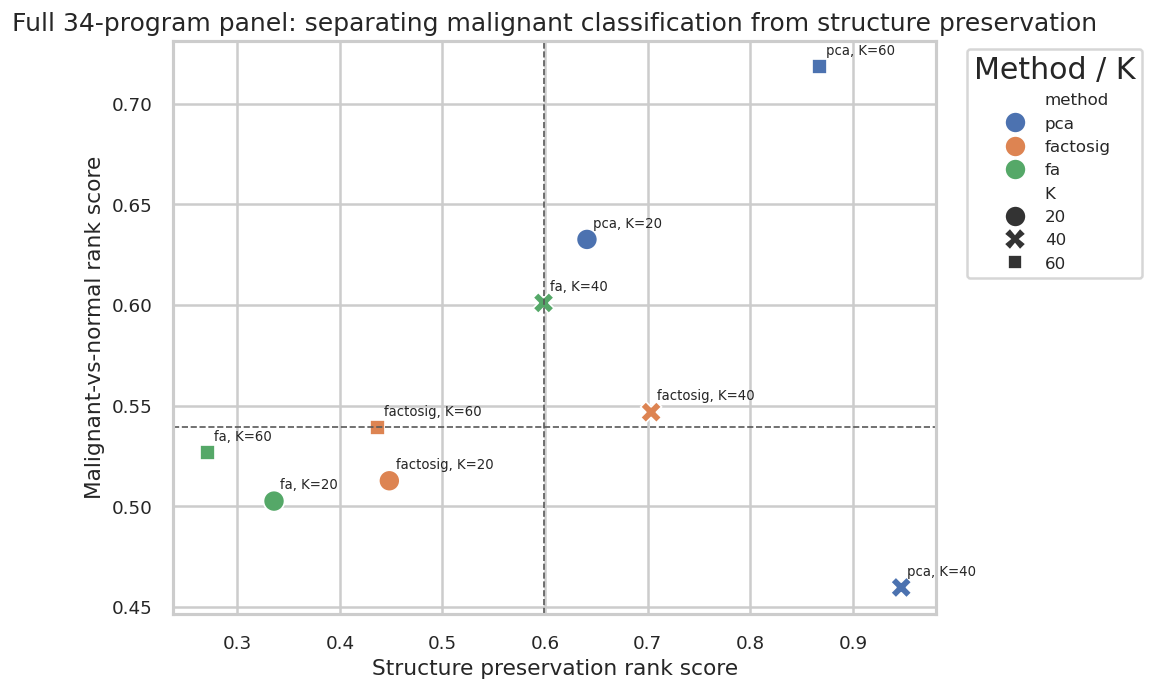

If one method/K is strong on both axes, it is a practical downstream pruning setting. If PCA is mainly strong on the structure axis, interpret that in light of possible reference-manifold bias because cell type and pseudotime may derive from PCA/kNN-style upstream workflows.

In [8]:
fig, ax = plt.subplots(figsize=(8.2, 6.2))
sns.scatterplot(
    data=full,
    x="structure_rank_score",
    y="malignancy_rank_score",
    hue="method",
    style="K",
    s=160,
    ax=ax,
)
for _, row in full.iterrows():
    ax.text(
        row["structure_rank_score"] + 0.006,
        row["malignancy_rank_score"] + 0.006,
        f"{row['method']}, K={int(row['K'])}",
        fontsize=8,
    )
ax.axvline(full["structure_rank_score"].median(), color="0.35", linestyle="--", linewidth=1)
ax.axhline(full["malignancy_rank_score"].median(), color="0.35", linestyle="--", linewidth=1)
ax.set_xlabel("Structure preservation rank score")
ax.set_ylabel("Malignant-vs-normal rank score")
ax.set_title("Full 34-program panel: separating malignant classification from structure preservation")
ax.legend(title="Method / K", bbox_to_anchor=(1.03, 1), loc="upper left")
save_figure(fig, "03_full34_malignancy_structure_scatter")
plt.show()

display(Markdown(
    "If one method/K is strong on both axes, it is a practical downstream pruning setting. "
    "If PCA is mainly strong on the structure axis, interpret that in light of possible reference-manifold bias because cell type and pseudotime may derive from PCA/kNN-style upstream workflows."
))

In [9]:
full_table_cols = [
    "panel", "method", "K",
    "across_mean_auroc", "across_mean_auprc", "within_mean_auroc",
    "celltype_knn_purity_macro", "pseudotime_knn_smoothness",
    "malignancy_rank_score", "structure_rank_score", "triage_score_refined",
]
full_table_cols = [c for c in full_table_cols if c in full.columns]
full_table = full[full_table_cols].sort_values("triage_score_refined", ascending=False)
display(full_table)

display(Markdown(
    "For `full_34`, `parsimony_bonus = 0`, so the triage score is the metric-rank score. "
    "The decomposed columns show whether each setting is strong because of malignant-vs-normal generalization, structure preservation, or both."
))

,panel,method,K,across_mean_auroc,across_mean_auprc,within_mean_auroc,celltype_knn_purity_macro,pseudotime_knn_smoothness,malignancy_rank_score,structure_rank_score,triage_score_refined
8,full_34,pca,60,0.860255,0.293155,0.925468,0.782861,0.798084,0.718434,0.867424,0.792929
42,full_34,pca,40,0.846835,0.254960,0.916604,0.784882,0.799208,0.459596,0.946970,0.703283
89,full_34,pca,20,0.876656,0.179540,0.897230,0.774511,0.796704,0.632576,0.640783,0.636679
99,full_34,factosig,40,0.858918,0.231462,0.918079,0.784896,0.782862,0.546717,0.703283,0.625000
124,full_34,fa,40,0.859415,0.252153,0.922330,0.782741,0.781041,0.601010,0.598485,0.599747
220,full_34,factosig,60,0.842512,0.310142,0.931245,0.778820,0.774279,0.539141,0.436869,0.488005
224,full_34,factosig,20,0.870078,0.167110,0.896504,0.769057,0.789281,0.512626,0.448232,0.480429
282,full_34,fa,20,0.869707,0.167019,0.898410,0.763725,0.785563,0.502525,0.335859,0.419192
300,full_34,fa,60,0.839044,0.319460,0.932728,0.773887,0.770179,0.526515,0.271465,0.398990


For `full_34`, `parsimony_bonus = 0`, so the triage score is the metric-rank score. The decomposed columns show whether each setting is strong because of malignant-vs-normal generalization, structure preservation, or both.

## 4. Choose Hyperparameter Settings for Downstream Pruning

Pruning effects are method/K-sensitive, so the selected downstream setting should come after inspecting the full-panel baseline. The primary setting below defaults to the best balanced full-panel setting, while secondary settings keep the best triage and best malignant-vs-normal settings available for sensitivity checks.

In [10]:
full_select = full.copy()
full_select["balanced_score_geomean"] = np.sqrt(
    full_select["malignancy_rank_score"].clip(lower=0) * full_select["structure_rank_score"].clip(lower=0)
)
full_select["balanced_score_min"] = full_select[["malignancy_rank_score", "structure_rank_score"]].min(axis=1)

selection_specs = [
    ("best original/refined triage", "triage_score_refined"),
    ("best malignancy", "malignancy_rank_score"),
    ("best balanced malignancy-structure", "balanced_score_geomean"),
]
selection_rows = []
for rule, col in selection_specs:
    row = full_select.sort_values([col, "triage_score_refined"], ascending=False).iloc[0]
    selection_rows.append({
        "selection_rule": rule,
        "method": row["method"],
        "K": int(row["K"]),
        "malignancy_rank_score": row["malignancy_rank_score"],
        "structure_rank_score": row["structure_rank_score"],
        "triage_score_refined": row["triage_score_refined"],
        "balanced_score_geomean": row["balanced_score_geomean"],
    })

selection_table = pd.DataFrame(selection_rows)
display(selection_table)

primary_row = selection_table.loc[
    selection_table["selection_rule"].eq("best balanced malignancy-structure")
].iloc[0]
PRIMARY_METHOD = str(primary_row["method"])
PRIMARY_K = int(primary_row["K"])

SECONDARY_SETTINGS = []

def add_setting(row: pd.Series) -> None:
    setting = (str(row["method"]), int(row["K"]))
    if setting not in SECONDARY_SETTINGS:
        SECONDARY_SETTINGS.append(setting)

# Start with the explicit selection rules.
for _, row in selection_table.iterrows():
    add_setting(row)

# If the rules collapse to the same setting, add the best setting per DR method
# and then top balanced alternatives so sensitivity remains informative.
for _, row in full_select.sort_values("triage_score_refined", ascending=False).groupby("method", as_index=False).head(1).iterrows():
    add_setting(row)
for _, row in full_select.sort_values("balanced_score_geomean", ascending=False).iterrows():
    add_setting(row)
    if len(SECONDARY_SETTINGS) >= 5:
        break

print("PRIMARY_METHOD =", PRIMARY_METHOD)
print("PRIMARY_K =", PRIMARY_K)
print("SECONDARY_SETTINGS =", SECONDARY_SETTINGS)

display(Markdown(
    f"Downstream pruning plots use `{PRIMARY_METHOD}`, `K={PRIMARY_K}` as the primary setting. "
    "Secondary settings include best rule-based choices plus strong full-panel alternatives, "
    "so the sensitivity section can check whether pruning conclusions are representation-specific."
))

,selection_rule,method,K,malignancy_rank_score,structure_rank_score,triage_score_refined,balanced_score_geomean
0,best original/refined triage,pca,60,0.718434,0.867424,0.792929,0.789422
1,best malignancy,pca,60,0.718434,0.867424,0.792929,0.789422
2,best balanced malignancy-structure,pca,60,0.718434,0.867424,0.792929,0.789422


PRIMARY_METHOD = pca
PRIMARY_K = 60
SECONDARY_SETTINGS = [('pca', 60), ('factosig', 40), ('fa', 40), ('pca', 40), ('pca', 20)]


Downstream pruning plots use `pca`, `K=60` as the primary setting. Secondary settings include best rule-based choices plus strong full-panel alternatives, so the sensitivity section can check whether pruning conclusions are representation-specific.

## 5. Matched Full-Panel Deltas for Pruning

Each pruned panel is compared with the `full_34` row having the same DR method and K. This avoids comparing every ablation to a global best full-panel setting.

In [11]:
df_delta = compute_matched_full_deltas(df)

required_delta_cols = [
    "delta_across_mean_auroc",
    "delta_across_mean_auprc",
    "delta_celltype_knn_purity_macro",
    "delta_pseudotime_knn_smoothness",
    "delta_malignancy_rank_score",
    "delta_structure_rank_score",
    "delta_metric_rank_score",
    "delta_triage_score",
]
missing_delta = [c for c in required_delta_cols if c not in df_delta.columns]
assert not missing_delta, missing_delta

pruned_delta = df_delta.loc[df_delta["status"].eq("ok") & ~df_delta["panel"].eq(PANEL_FULL)].copy()
print("df_delta shape:", df_delta.shape)
print("pruned rows:", pruned_delta.shape)
display(
    pruned_delta[[
        "panel", "panel_type", "method", "K", "dropped_geneset",
        "delta_across_mean_auroc", "delta_across_mean_auprc",
        "delta_malignancy_rank_score", "delta_structure_rank_score", "delta_triage_score",
    ]].head(10)
)

df_delta shape: (396, 88)
pruned rows: (387, 88)


,panel,panel_type,method,K,dropped_geneset,delta_across_mean_auroc,delta_across_mean_auprc,delta_malignancy_rank_score,delta_structure_rank_score,delta_triage_score
0,drop_geneset__reactome_mhc_class_i_antigen_pre...,leave_one_geneset_out_strict_gene_ablation,pca,40,REACTOME_MHC_CLASS_I_ANTIGEN_PRESENTATION,1.191537e-02,5.892569e-02,0.284091,-0.032828,0.142752
1,drop_geneset__hallmark_g2m_checkpoint,leave_one_geneset_out_strict_gene_ablation,pca,40,HALLMARK_G2M_CHECKPOINT,9.286159e-03,5.884307e-02,0.237374,0.029040,0.142162
2,drop_geneset__reactome_interferon_signaling,leave_one_geneset_out_strict_gene_ablation,pca,40,REACTOME_INTERFERON_SIGNALING,8.973597e-03,3.194790e-02,0.176768,0.035354,0.118773
3,drop_geneset__hallmark_dna_repair,leave_one_geneset_out_strict_gene_ablation,pca,40,HALLMARK_DNA_REPAIR,6.997533e-03,5.205568e-02,0.191919,0.017677,0.111711
4,drop_geneset__hallmark_e2f_targets,leave_one_geneset_out_strict_gene_ablation,pca,40,HALLMARK_E2F_TARGETS,5.907621e-03,3.883804e-02,0.151515,0.051768,0.110828
5,drop_group__tgf_plasticity,group_dropout_strict_gene_ablation,pca,40,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION + H...,1.738337e-02,1.266766e-01,0.393939,-0.196970,0.109898
6,drop_geneset__hallmark_tgf_beta_signaling,leave_one_geneset_out_strict_gene_ablation,pca,40,HALLMARK_TGF_BETA_SIGNALING,1.074964e-02,3.049719e-02,0.205808,-0.016414,0.097202
7,redundancy_pruned_jaccard50,redundancy_pruned,pca,60,None,1.088573e-08,4.073771e-10,0.002525,0.000000,0.001263
9,drop_geneset__hallmark_tnfa_signaling_via_nfkb,leave_one_geneset_out_strict_gene_ablation,pca,60,HALLMARK_TNFA_SIGNALING_VIA_NFKB,4.147888e-03,3.262018e-02,0.103535,-0.123737,-0.000868
10,drop_geneset__kegg_antigen_processing_and_pres...,leave_one_geneset_out_strict_gene_ablation,pca,40,KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION,1.045908e-02,1.459833e-02,0.160354,0.005051,0.085950


## 6. Pruning Overview Under the Selected Hyperparameter

The main pruning section focuses on leave-one-program-out rows under the selected full-panel setting. Group-dropout and redundancy-pruned panels can still be inspected from `df_delta`, but single-program ablations are the clearest unit for theme summaries.

In [12]:
LEAVE_ONE_PANEL_TYPE = "leave_one_geneset_out_strict_gene_ablation"

df_primary = df_delta.loc[
    df_delta["status"].eq("ok")
    & df_delta["method"].eq(PRIMARY_METHOD)
    & df_delta["K"].eq(PRIMARY_K)
    & df_delta["panel_type"].eq(LEAVE_ONE_PANEL_TYPE)
].copy()

if df_primary.empty:
    raise ValueError(f"No leave-one-gene-set rows for {PRIMARY_METHOD}, K={PRIMARY_K}.")

print("Primary setting:", PRIMARY_METHOD, PRIMARY_K)
print("Primary leave-one rows:", df_primary.shape)
print("Dropped gene sets:")
display(pd.Series(sorted(df_primary["dropped_geneset"].dropna().unique()), name="dropped_geneset"))

# Manually editable broad-theme mapping. Only gene sets present in the old 34-set panel are included.
THEME_MAP = {
    # Inflammatory / cytokine signaling
    "HALLMARK_INTERFERON_GAMMA_RESPONSE": "Inflammatory / cytokine signaling",
    "HALLMARK_INTERFERON_ALPHA_RESPONSE": "Inflammatory / cytokine signaling",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB": "Inflammatory / cytokine signaling",
    "HALLMARK_INFLAMMATORY_RESPONSE": "Inflammatory / cytokine signaling",
    "HALLMARK_IL6_JAK_STAT3_SIGNALING": "Inflammatory / cytokine signaling",
    "HALLMARK_IL2_STAT5_SIGNALING": "Inflammatory / cytokine signaling",
    "REACTOME_INTERFERON_SIGNALING": "Inflammatory / cytokine signaling",
    "REACTOME_INTERFERON_GAMMA_SIGNALING": "Inflammatory / cytokine signaling",
    "REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM": "Inflammatory / cytokine signaling",
    "REACTOME_NF_KB_ACTIVATION": "Inflammatory / cytokine signaling",
    "REACTOME_TNFR1_INDUCED_NFKB_SIGNALING_PATHWAY": "Inflammatory / cytokine signaling",
    "KEGG_JAK_STAT_SIGNALING_PATHWAY": "Inflammatory / cytokine signaling",

    # Antigen presentation / immune interface
    "HALLMARK_ALLOGRAFT_REJECTION": "Antigen presentation / immune interface",
    "REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMBLY_AND_PEPTIDE_LOADING_OF_CLASS_I_MHC": "Antigen presentation / immune interface",
    "REACTOME_MHC_CLASS_I_ANTIGEN_PRESENTATION": "Antigen presentation / immune interface",
    "REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION": "Antigen presentation / immune interface",
    "KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION": "Antigen presentation / immune interface",

    # Cell cycle / proliferation
    "HALLMARK_E2F_TARGETS": "Cell cycle / proliferation",
    "HALLMARK_G2M_CHECKPOINT": "Cell cycle / proliferation",
    "HALLMARK_MYC_TARGETS_V1": "Cell cycle / proliferation",
    "HALLMARK_MYC_TARGETS_V2": "Cell cycle / proliferation",

    # Stress / quiescence / survival
    "HALLMARK_APOPTOSIS": "Stress / quiescence / survival",
    "HALLMARK_P53_PATHWAY": "Stress / quiescence / survival",
    "HALLMARK_HYPOXIA": "Stress / quiescence / survival",
    "HALLMARK_UNFOLDED_PROTEIN_RESPONSE": "Stress / quiescence / survival",
    "HALLMARK_DNA_REPAIR": "Stress / quiescence / survival",
    "HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY": "Stress / quiescence / survival",

    # Metabolism
    "HALLMARK_OXIDATIVE_PHOSPHORYLATION": "Metabolism",
    "HALLMARK_GLYCOLYSIS": "Metabolism",
    "HALLMARK_MTORC1_SIGNALING": "Metabolism",

    # Adhesion / migration / niche interaction
    "HALLMARK_TGF_BETA_SIGNALING": "Adhesion / migration / niche interaction",
    "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION": "Adhesion / migration / niche interaction",

    # Innate immune context
    "HALLMARK_COMPLEMENT": "Inflammatory / innate immune context",
    "KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY": "Inflammatory / innate immune context",
}

def add_theme_column(frame: pd.DataFrame, geneset_col: str = "dropped_geneset") -> pd.DataFrame:
    out = frame.copy()
    out["theme"] = out[geneset_col].map(THEME_MAP).fillna("Other / unmapped")
    return out

df_primary = add_theme_column(df_primary)
unmapped = sorted(set(df_primary["dropped_geneset"].dropna()) - set(THEME_MAP))
print("Unmapped gene sets:")
print(unmapped)

geneset_count_table = make_geneset_count_table(per_geneset_hvg_overlap)
theme_count_table = make_theme_count_table(per_geneset_hvg_overlap, THEME_MAP)
df_primary = add_geneset_count_labels(df_primary, geneset_count_table)
df_primary = add_theme_count_labels(df_primary, theme_count_table)

theme_palette = make_theme_palette(df_primary["theme"])
display(
    df_primary[[
        "dropped_geneset", "dropped_geneset_label", "theme", "theme_label",
        "geneset_n_genes", "geneset_n_hvg_genes", "geneset_hvg_fraction",
    ]]
    .drop_duplicates()
    .sort_values(["theme", "dropped_geneset"])
)

Primary setting: pca 60
Primary leave-one rows: (34, 88)
Dropped gene sets:


0                          HALLMARK_ALLOGRAFT_REJECTION
1                                    HALLMARK_APOPTOSIS
2                                   HALLMARK_COMPLEMENT
3                                   HALLMARK_DNA_REPAIR
4                                  HALLMARK_E2F_TARGETS
5            HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION
6                               HALLMARK_G2M_CHECKPOINT
7                                   HALLMARK_GLYCOLYSIS
8                                      HALLMARK_HYPOXIA
9                          HALLMARK_IL2_STAT5_SIGNALING
10                     HALLMARK_IL6_JAK_STAT3_SIGNALING
11                       HALLMARK_INFLAMMATORY_RESPONSE
12                   HALLMARK_INTERFERON_ALPHA_RESPONSE
13                   HALLMARK_INTERFERON_GAMMA_RESPONSE
14                            HALLMARK_MTORC1_SIGNALING
15                              HALLMARK_MYC_TARGETS_V1
16                              HALLMARK_MYC_TARGETS_V2
17                   HALLMARK_OXIDATIVE_PHOSPHOR

Unmapped gene sets:
[]


,dropped_geneset,dropped_geneset_label,theme,theme_label,geneset_n_genes,geneset_n_hvg_genes,geneset_hvg_fraction
8,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION\n(n...,Adhesion / migration / niche interaction,Adhesion / migration / niche\ninteraction\n(n=...,197,109,0.553299
30,HALLMARK_TGF_BETA_SIGNALING,HALLMARK_TGF_BETA_SIGNALING\n(n=54; HVG=27/54 ...,Adhesion / migration / niche interaction,Adhesion / migration / niche\ninteraction\n(n=...,54,27,0.5
31,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ALLOGRAFT_REJECTION\n(n=190; HVG=110/...,Antigen presentation / immune interface,Antigen presentation / immune\ninterface\n(n=6...,190,110,0.578947
15,KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION,KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION\n(n=7...,Antigen presentation / immune interface,Antigen presentation / immune\ninterface\n(n=6...,70,35,0.5
5,REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMBLY...,REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMB\n...,Antigen presentation / immune interface,Antigen presentation / immune\ninterface\n(n=6...,29,2,0.068966
19,REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION,REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION\n(n...,Antigen presentation / immune interface,Antigen presentation / immune\ninterface\n(n=6...,121,52,0.429752
26,REACTOME_MHC_CLASS_I_ANTIGEN_PRESENTATION,REACTOME_MHC_CLASS_I_ANTIGEN_PRESENTATION\n(n=...,Antigen presentation / immune interface,Antigen presentation / immune\ninterface\n(n=6...,369,92,0.249322
7,HALLMARK_E2F_TARGETS,HALLMARK_E2F_TARGETS\n(n=198; HVG=126/198 (64%)),Cell cycle / proliferation,Cell cycle / proliferation\n(n=504; HVG=283/50...,198,126,0.636364
25,HALLMARK_G2M_CHECKPOINT,HALLMARK_G2M_CHECKPOINT\n(n=193; HVG=123/193 (...,Cell cycle / proliferation,Cell cycle / proliferation\n(n=504; HVG=283/50...,193,123,0.637306
4,HALLMARK_MYC_TARGETS_V1,HALLMARK_MYC_TARGETS_V1\n(n=195; HVG=101/195 (...,Cell cycle / proliferation,Cell cycle / proliferation\n(n=504; HVG=283/50...,195,101,0.517949


Saved figures/geneset_pruning_refined/04_primary_pruning_delta_triage_barplot.png
Saved figures/geneset_pruning_refined/04_primary_pruning_delta_triage_barplot.pdf


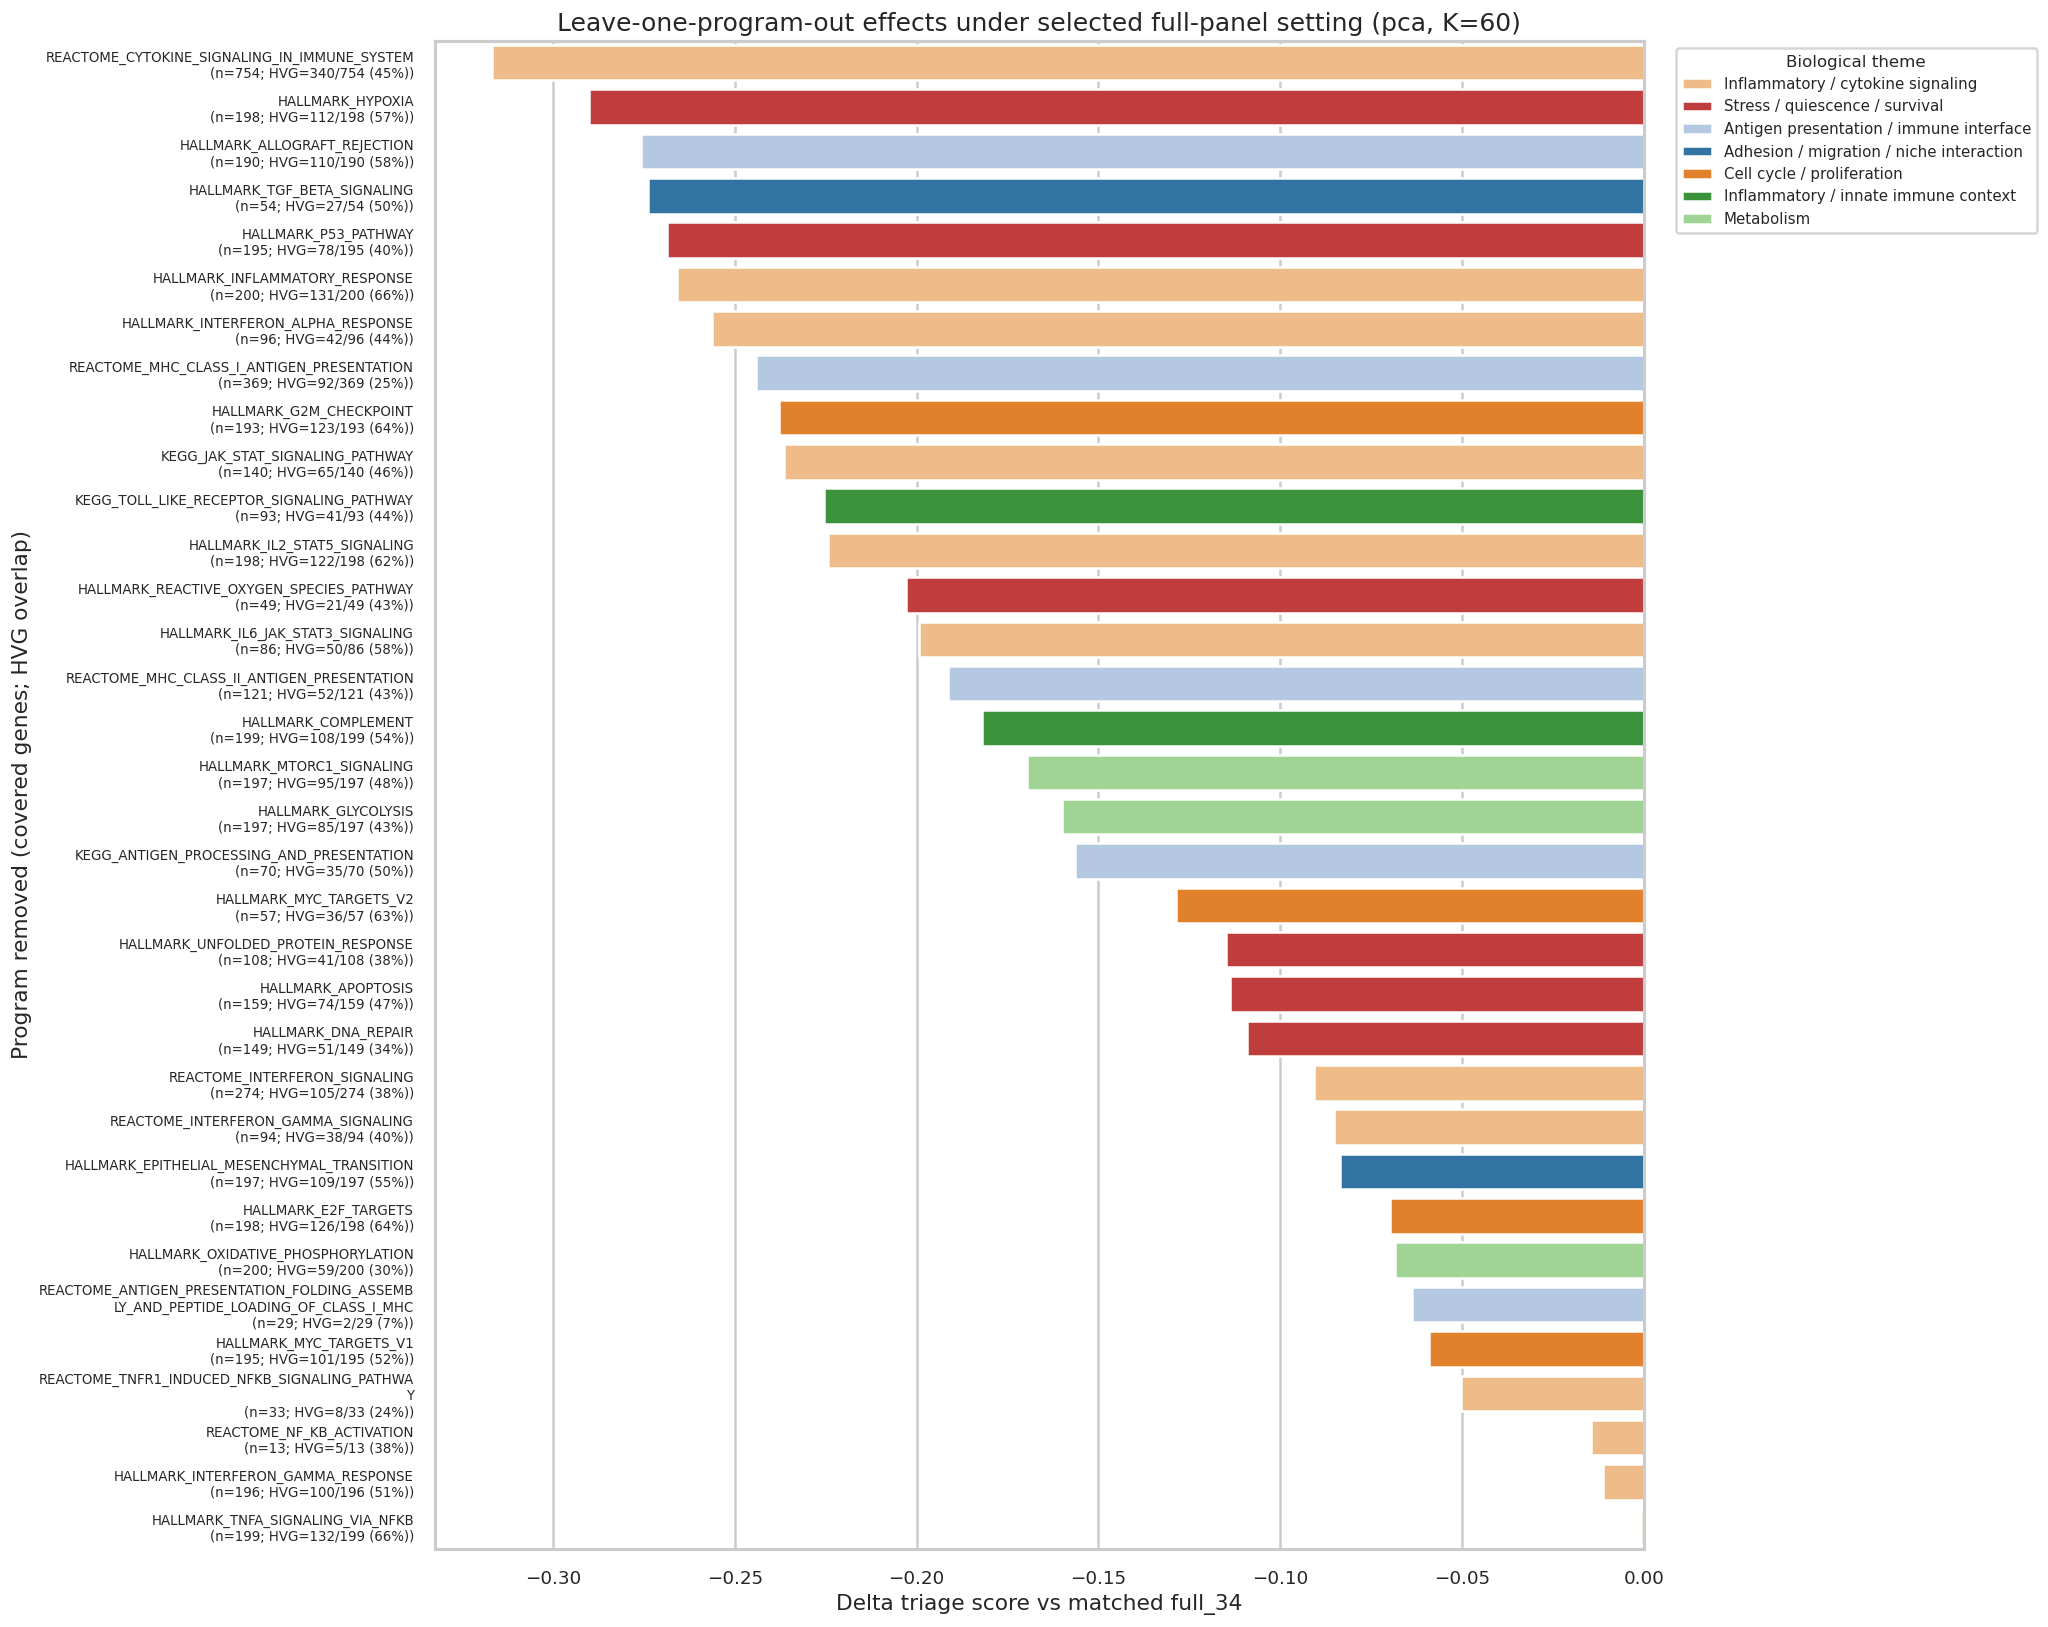

In [13]:
plot_df = df_primary.sort_values("delta_triage_score", ascending=True).copy()
fig_height = max(10, 0.48 * len(plot_df))
fig, ax = plt.subplots(figsize=(13, fig_height))
sns.barplot(
    data=plot_df,
    x="delta_triage_score",
    y="dropped_geneset_label",
    hue="theme",
    dodge=False,
    palette=theme_palette,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Delta triage score vs matched full_34")
ax.set_ylabel("Program removed (covered genes; HVG overlap)")
ax.set_title(f"Leave-one-program-out effects under selected full-panel setting ({PRIMARY_METHOD}, K={PRIMARY_K})")
ax.tick_params(axis="y", labelsize=8)
ax.legend(title="Biological theme", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title_fontsize=10)
save_figure(fig, "04_primary_pruning_delta_triage_barplot")
plt.show()

Saved figures/geneset_pruning_refined/05_primary_pruning_delta_malignancy_vs_structure.png
Saved figures/geneset_pruning_refined/05_primary_pruning_delta_malignancy_vs_structure.pdf


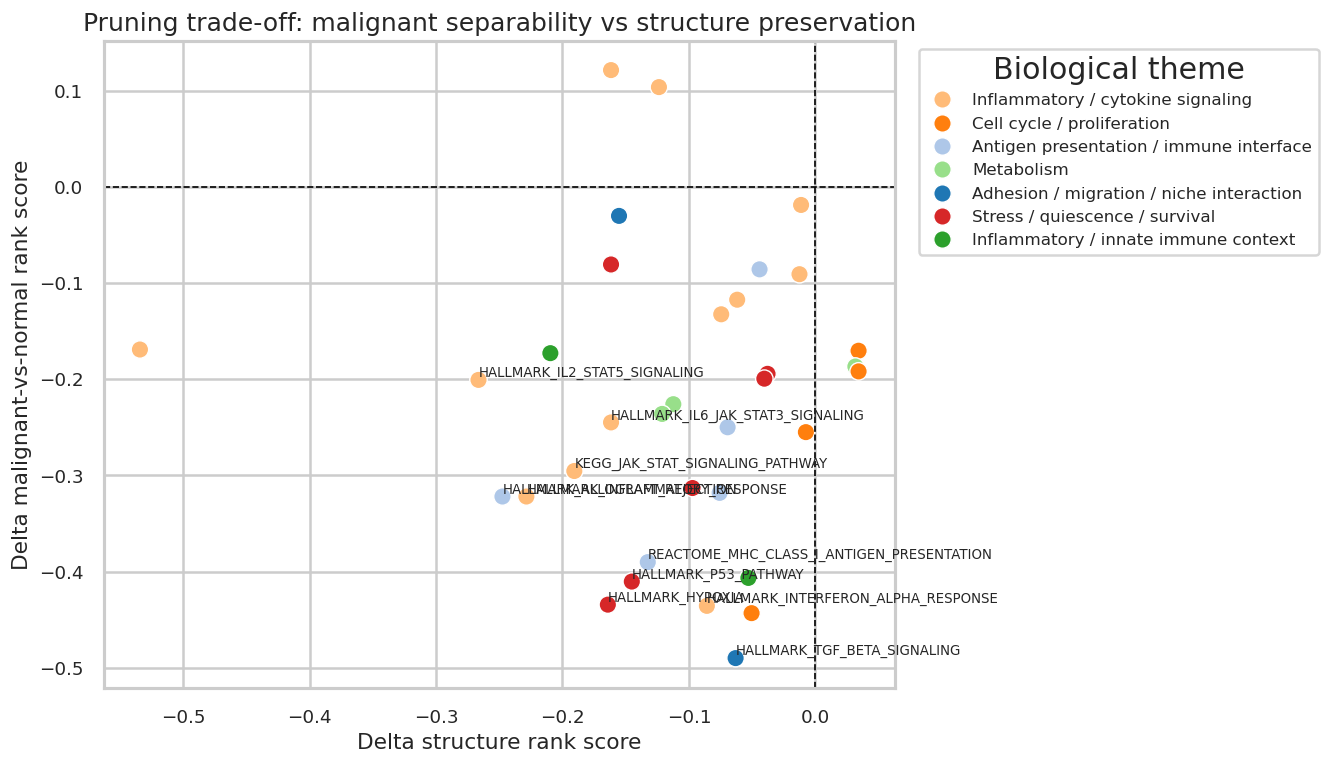

Quadrants: lower-left means removal damages both malignant separability and structure; lower-right damages malignant separability while preserving/improving structure; upper-left preserves/improves malignant separability while damaging structure; upper-right suggests redundancy or noise under this score.

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.scatterplot(
    data=df_primary,
    x="delta_structure_rank_score",
    y="delta_malignancy_rank_score",
    hue="theme",
    palette=theme_palette,
    s=110,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.axhline(0, color="black", linewidth=1, linestyle="--")
label_extreme_points(
    ax,
    df_primary,
    x="delta_structure_rank_score",
    y="delta_malignancy_rank_score",
    label="dropped_geneset",
    n=10,
)
ax.set_xlabel("Delta structure rank score")
ax.set_ylabel("Delta malignant-vs-normal rank score")
ax.set_title("Pruning trade-off: malignant separability vs structure preservation")
ax.legend(title="Biological theme", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure(fig, "05_primary_pruning_delta_malignancy_vs_structure")
plt.show()

display(Markdown(
    "Quadrants: lower-left means removal damages both malignant separability and structure; "
    "lower-right damages malignant separability while preserving/improving structure; "
    "upper-left preserves/improves malignant separability while damaging structure; "
    "upper-right suggests redundancy or noise under this score."
))

Saved figures/geneset_pruning_refined/06_primary_pruning_raw_delta_heatmap.png
Saved figures/geneset_pruning_refined/06_primary_pruning_raw_delta_heatmap.pdf


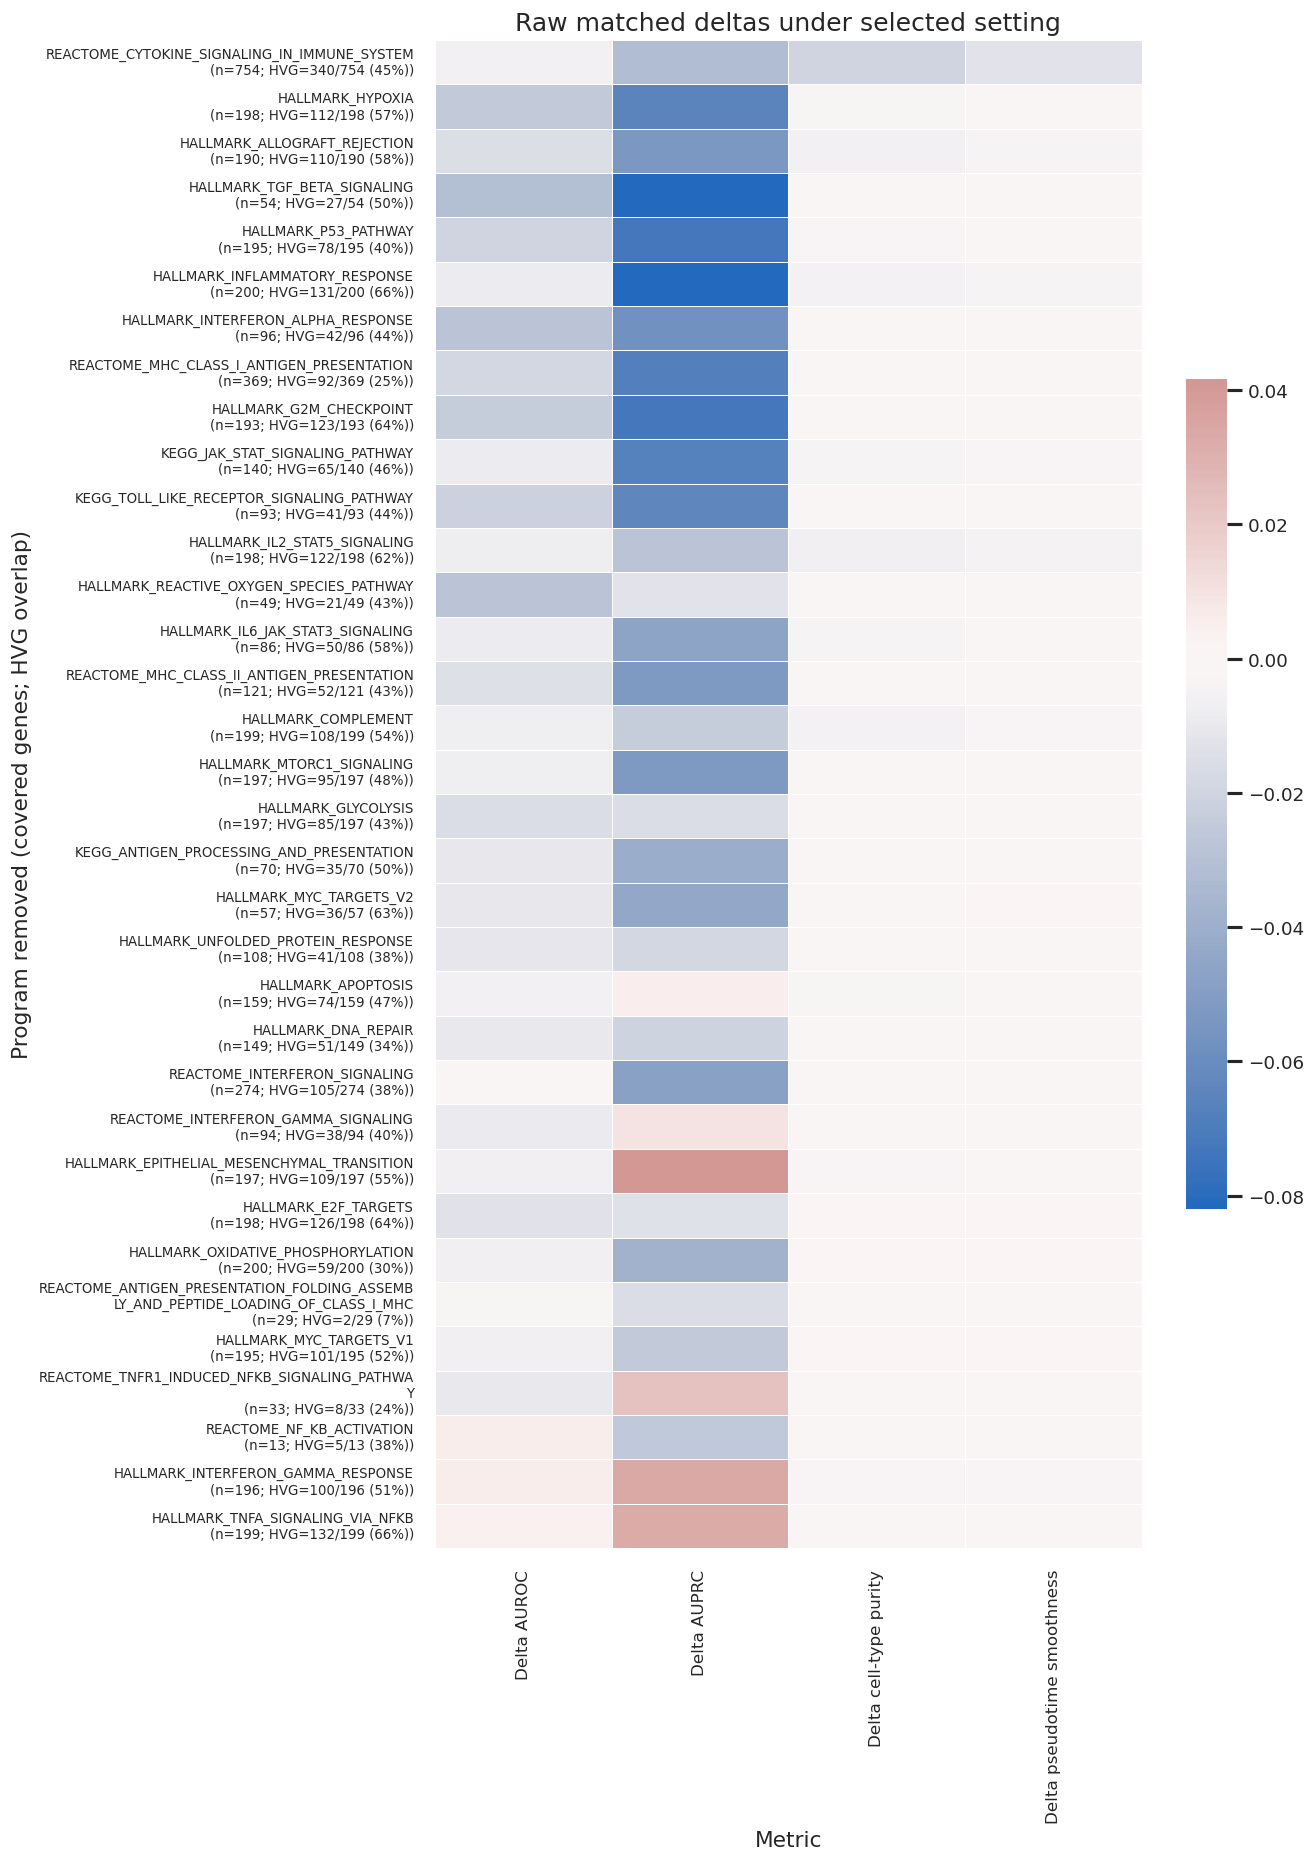

In [15]:
raw_delta_cols = [
    "delta_across_mean_auroc",
    "delta_across_mean_auprc",
    "delta_celltype_knn_purity_macro",
    "delta_pseudotime_knn_smoothness",
]
heat_df = (
    df_primary.sort_values("delta_triage_score")
    .set_index("dropped_geneset_label")[raw_delta_cols]
    .rename(columns={
        "delta_across_mean_auroc": "Delta AUROC",
        "delta_across_mean_auprc": "Delta AUPRC",
        "delta_celltype_knn_purity_macro": "Delta cell-type purity",
        "delta_pseudotime_knn_smoothness": "Delta pseudotime smoothness",
    })
)
fig, ax = plt.subplots(figsize=(9.5, max(10, 0.48 * len(heat_df))))
sns.heatmap(heat_df, cmap="vlag", center=0, linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.55})
ax.set_title("Raw matched deltas under selected setting")
ax.set_xlabel("Metric")
ax.set_ylabel("Program removed (covered genes; HVG overlap)")
ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", labelsize=10)
save_figure(fig, "06_primary_pruning_raw_delta_heatmap")
plt.show()

## 8. Theme-Level Summaries

Theme-level summaries reduce the temptation to overinterpret a single extreme gene set. Negative deltas indicate that removing the program or theme made the score worse relative to the matched full panel.

,theme,n_genesets,mean_delta_triage_score,median_delta_triage_score,min_delta_triage_score,mean_delta_malignancy_rank_score,mean_delta_structure_rank_score,mean_delta_across_auroc,mean_delta_across_auprc,theme_n_genes,theme_n_hvg_genes,theme_hvg_fraction,theme_count_suffix,theme_label
4,Inflammatory / innate immune context,2,-0.203769,-0.203769,-0.225483,-0.289773,-0.131313,-0.014511,-0.043488,286,144,0.503497,n=286; HVG=144/286 (50%),Inflammatory / innate immune\ncontext\n(n=286;...
1,Antigen presentation / immune interface,5,-0.186332,-0.191356,-0.275907,-0.273232,-0.113889,-0.012444,-0.046030,675,262,0.388148,n=675; HVG=262/675 (39%),Antigen presentation / immune\ninterface\n(n=6...
6,Stress / quiescence / survival,6,-0.183285,-0.158921,-0.290056,-0.272096,-0.107744,-0.016832,-0.030765,785,337,0.429299,n=785; HVG=337/785 (43%),Stress / quiescence / survival\n(n=785; HVG=33...
0,Adhesion / migration / niche interaction,2,-0.178836,-0.178836,-0.274010,-0.260101,-0.109217,-0.019204,-0.020177,246,132,0.536585,n=246; HVG=132/246 (54%),Adhesion / migration / niche\ninteraction\n(n=...
3,Inflammatory / cytokine signaling,12,-0.146003,-0.145058,-0.316658,-0.150253,-0.159407,-0.006004,-0.023943,1270,621,0.488976,n=1270; HVG=621/1270 (49%),Inflammatory / cytokine signaling\n(n=1270; HV...
5,Metabolism,3,-0.132649,-0.160052,-0.169521,-0.216330,-0.067340,-0.009814,-0.034904,554,216,0.389892,n=554; HVG=216/554 (39%),Metabolism\n(n=554; HVG=216/554 (39%))
2,Cell cycle / proliferation,4,-0.123855,-0.099198,-0.237889,-0.265152,0.002525,-0.013711,-0.038950,504,283,0.561508,n=504; HVG=283/504 (56%),Cell cycle / proliferation\n(n=504; HVG=283/50...


Saved figures/geneset_pruning_refined/07_theme_level_pruning_summary.png
Saved figures/geneset_pruning_refined/07_theme_level_pruning_summary.pdf


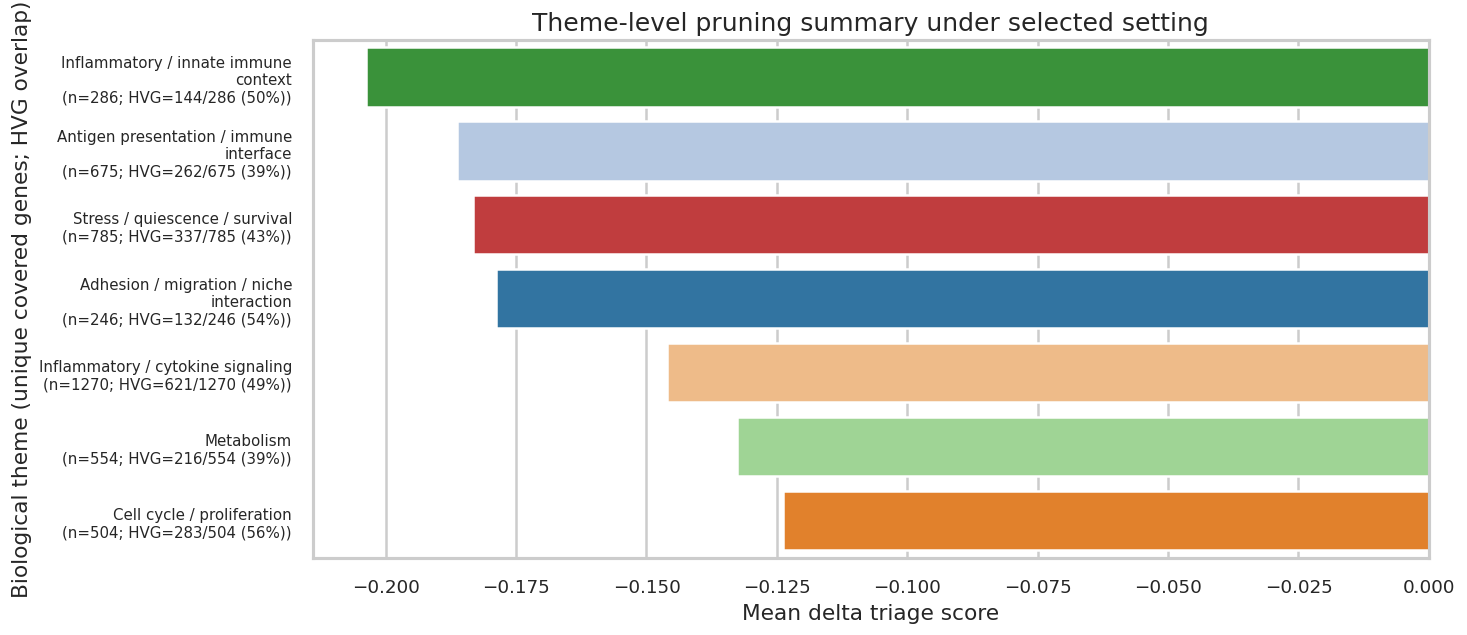

Saved figures/geneset_pruning_refined/08_theme_level_malignancy_vs_structure.png
Saved figures/geneset_pruning_refined/08_theme_level_malignancy_vs_structure.pdf


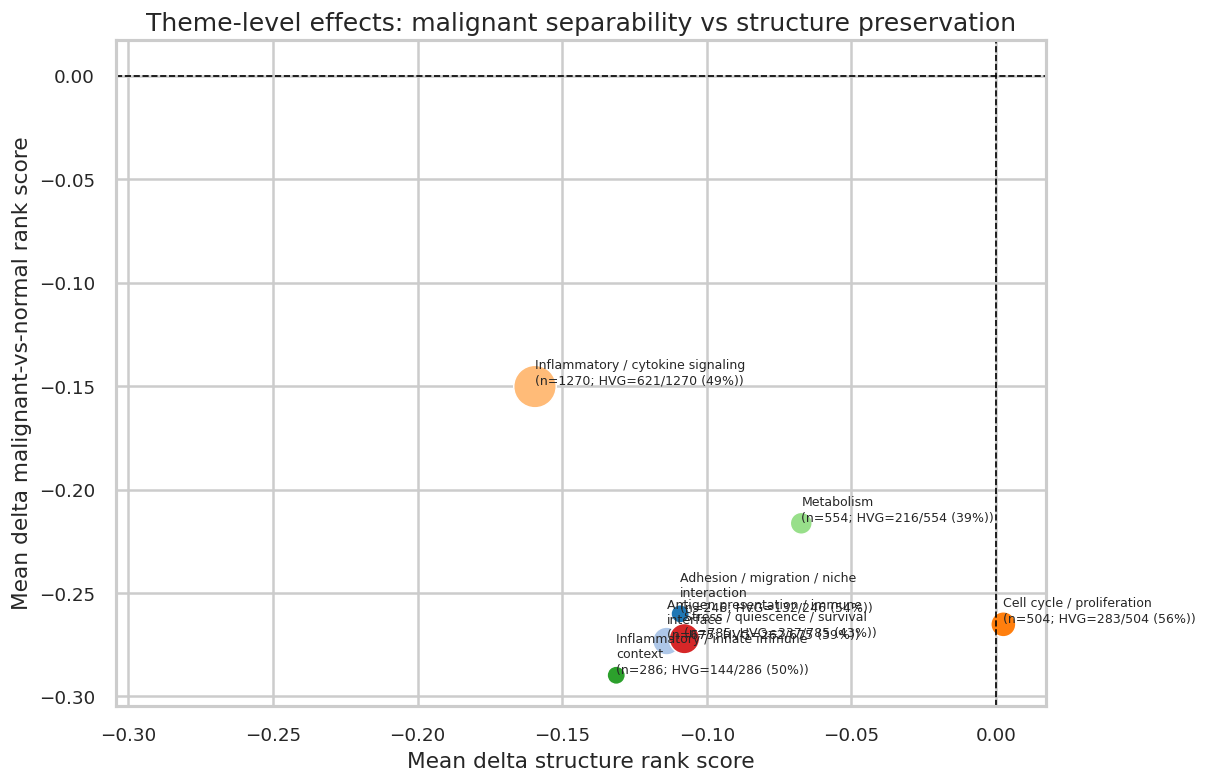

Themes with negative mean malignancy delta contribute to malignant-vs-normal separation. Themes with negative mean structure delta help preserve cell-type/pseudotime organization. If many themes are modestly negative rather than one theme collapsing performance, that supports distributed MRD biology.

In [16]:
theme_summary = (
    df_primary.groupby("theme", as_index=False)
    .agg(
        n_genesets=("dropped_geneset", "nunique"),
        mean_delta_triage_score=("delta_triage_score", "mean"),
        median_delta_triage_score=("delta_triage_score", "median"),
        min_delta_triage_score=("delta_triage_score", "min"),
        mean_delta_malignancy_rank_score=("delta_malignancy_rank_score", "mean"),
        mean_delta_structure_rank_score=("delta_structure_rank_score", "mean"),
        mean_delta_across_auroc=("delta_across_mean_auroc", "mean"),
        mean_delta_across_auprc=("delta_across_mean_auprc", "mean"),
    )
    .merge(theme_count_table, on="theme", how="left")
    .sort_values("mean_delta_triage_score")
)
theme_summary["theme_label"] = theme_summary.apply(
    lambda r: append_count_suffix(r["theme"], r.get("theme_count_suffix"), width=34),
    axis=1,
)
display(theme_summary)

fig, ax = plt.subplots(figsize=(12, max(5.5, 0.8 * len(theme_summary))))
sns.barplot(
    data=theme_summary,
    y="theme_label",
    x="mean_delta_triage_score",
    hue="theme",
    palette=theme_palette,
    dodge=False,
    ax=ax,
)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Mean delta triage score")
ax.set_ylabel("Biological theme (unique covered genes; HVG overlap)")
ax.set_title("Theme-level pruning summary under selected setting")
ax.tick_params(axis="y", labelsize=9)
save_figure(fig, "07_theme_level_pruning_summary")
plt.show()

fig, ax = plt.subplots(figsize=(10, 7.2))
sns.scatterplot(
    data=theme_summary,
    x="mean_delta_structure_rank_score",
    y="mean_delta_malignancy_rank_score",
    size="n_genesets",
    sizes=(120, 650),
    hue="theme",
    palette=theme_palette,
    ax=ax,
)
for _, row in theme_summary.iterrows():
    ax.text(
        row["mean_delta_structure_rank_score"],
        row["mean_delta_malignancy_rank_score"],
        row["theme_label"],
        fontsize=7.5,
        ha="left",
        va="bottom",
    )

xy_values = theme_summary[
    ["mean_delta_structure_rank_score", "mean_delta_malignancy_rank_score"]
].to_numpy(dtype=float).ravel()
xy_values = xy_values[np.isfinite(xy_values)]
xy_min = min(float(xy_values.min()), 0.0)
xy_max = max(float(xy_values.max()), 0.0)
xy_pad = 0.05 * (xy_max - xy_min) if xy_max > xy_min else 0.01
xy_limits = (xy_min - xy_pad, xy_max + xy_pad)

ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlim(xy_limits)
ax.set_ylim(xy_limits)
ax.set_xlabel("Mean delta structure rank score")
ax.set_ylabel("Mean delta malignant-vs-normal rank score")
ax.set_title("Theme-level effects: malignant separability vs structure preservation")
legend = ax.get_legend()
if legend is not None:
    legend.remove()
save_figure(fig, "08_theme_level_malignancy_vs_structure")
plt.show()

display(Markdown(
    "Themes with negative mean malignancy delta contribute to malignant-vs-normal separation. "
    "Themes with negative mean structure delta help preserve cell-type/pseudotime organization. "
    "If many themes are modestly negative rather than one theme collapsing performance, that supports distributed MRD biology."
))

## 9. Sensitivity Across DR Method/K

The question here is whether the same biological themes are repeatedly damaging when removed, or whether pruning conclusions depend strongly on the latent representation. Single-gene-set conclusions should be treated as hypothesis-generating when method/K sensitivity is high.

Sensitivity settings across all methods/K:


,method,K
0,fa,20
1,fa,40
2,fa,60
3,factosig,20
4,factosig,40
5,factosig,60
6,pca,20
7,pca,40
8,pca,60


Sensitivity rows: (306, 90)


,setting_label,method,K,theme,n_genesets,mean_delta_triage_score,mean_delta_malignancy_rank_score,mean_delta_structure_rank_score
4,"fa, K=20",fa,20,Inflammatory / innate immune context,2,-0.039628,-0.128157,0.035354
3,"fa, K=20",fa,20,Inflammatory / cytokine signaling,12,-0.038890,-0.087226,-0.008207
6,"fa, K=20",fa,20,Stress / quiescence / survival,6,-0.008832,-0.072180,0.041246
1,"fa, K=20",fa,20,Antigen presentation / immune interface,5,-0.002746,-0.021465,0.001515
0,"fa, K=20",fa,20,Adhesion / migration / niche interaction,2,0.008348,-0.022096,0.027146
...,...,...,...,...,...,...,...,...
62,"pca, K=60",pca,60,Stress / quiescence / survival,6,-0.183285,-0.272096,-0.107744
56,"pca, K=60",pca,60,Adhesion / migration / niche interaction,2,-0.178836,-0.260101,-0.109217
59,"pca, K=60",pca,60,Inflammatory / cytokine signaling,12,-0.146003,-0.150253,-0.159407
61,"pca, K=60",pca,60,Metabolism,3,-0.132649,-0.216330,-0.067340


Saved figures/geneset_pruning_refined/09_theme_sensitivity_across_settings.png
Saved figures/geneset_pruning_refined/09_theme_sensitivity_across_settings.pdf


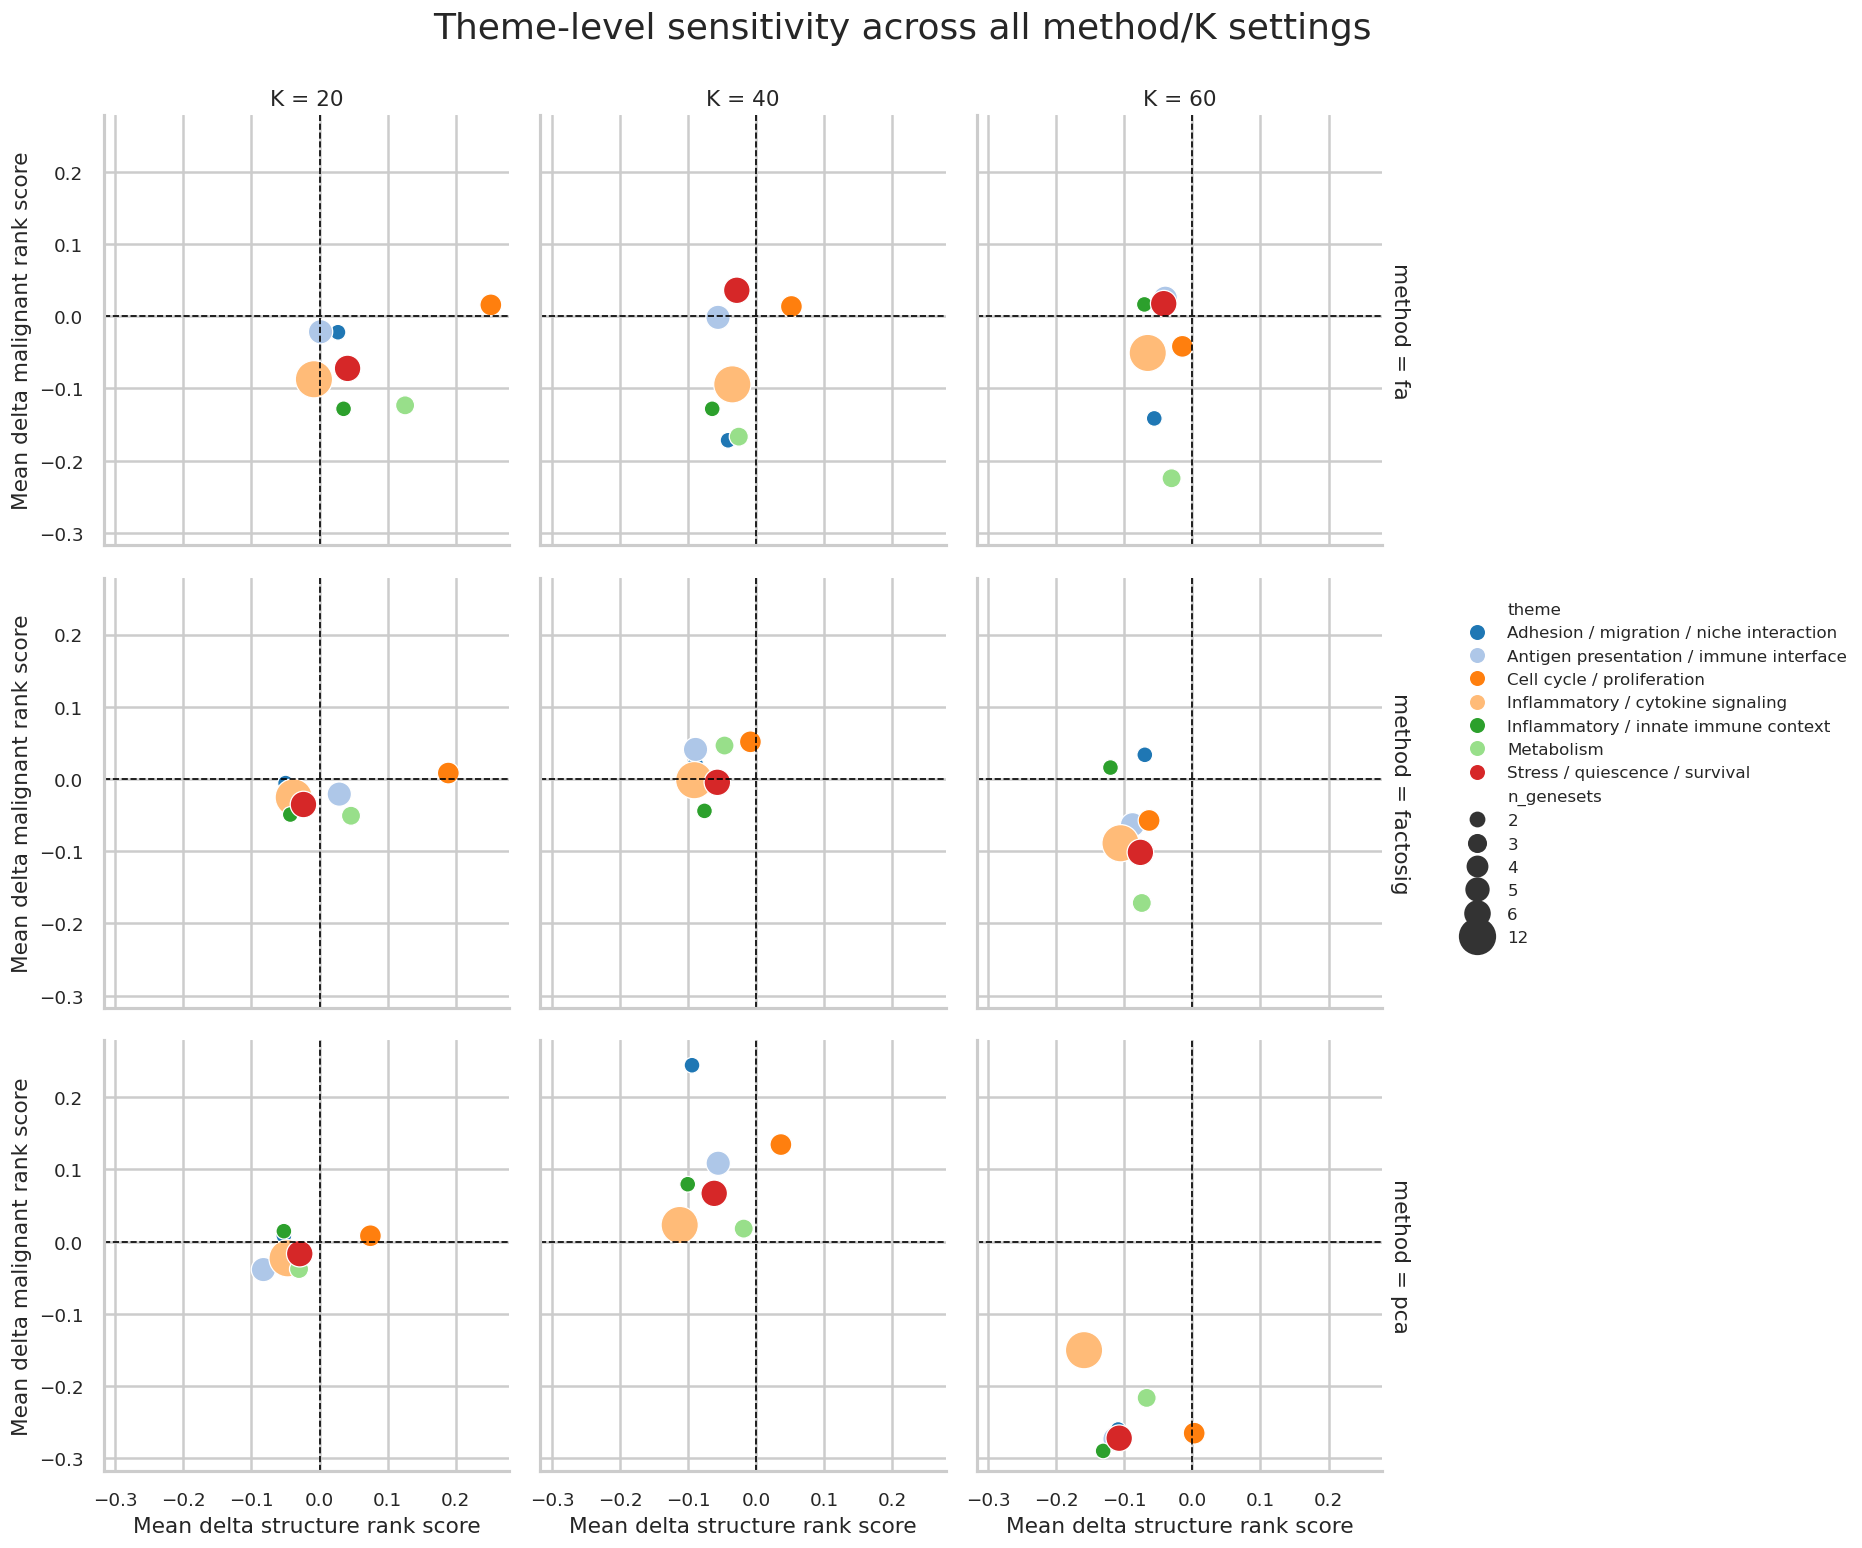

,theme,n_settings,mean_delta_triage_mean,mean_delta_triage_std,fraction_negative_triage,mean_delta_malignancy_mean,mean_delta_structure_mean
4,Inflammatory / innate immune context,9,-0.056357,0.060777,1.000000,-0.057029,-0.069234
3,Inflammatory / cytokine signaling,9,-0.055643,0.039116,1.000000,-0.055415,-0.073525
0,Adhesion / migration / niche interaction,9,-0.040193,0.074587,0.777778,-0.032618,-0.059414
6,Stress / quiescence / survival,9,-0.035956,0.061681,0.777778,-0.042462,-0.042719
1,Antigen presentation / immune interface,9,-0.033814,0.065174,0.777778,-0.027189,-0.054896
5,Metabolism,9,-0.048976,0.062709,0.555556,-0.102974,-0.013351
2,Cell cycle / proliferation,9,0.029011,0.083512,0.333333,-0.014731,0.057835


Pruning deltas vary substantially across DR method/K settings. Emphasize themes that are repeatedly damaging, not individual gene sets that are extreme under one representation.

In [17]:
sensitivity = df_delta.loc[
    df_delta["status"].eq("ok")
    & df_delta["panel_type"].eq(LEAVE_ONE_PANEL_TYPE)
].copy()
sensitivity["K"] = pd.to_numeric(sensitivity["K"], errors="coerce")
sensitivity = sensitivity.loc[sensitivity["K"].notna()].copy()
sensitivity["K"] = sensitivity["K"].astype(int)
sensitivity = add_theme_column(sensitivity)
sensitivity["setting_label"] = sensitivity["method"] + ", K=" + sensitivity["K"].astype(str)

settings_df = (
    sensitivity[["method", "K"]]
    .drop_duplicates()
    .sort_values(["method", "K"])
    .reset_index(drop=True)
)
method_order = settings_df["method"].drop_duplicates().tolist()
k_order = sorted(settings_df["K"].unique())

print("Sensitivity settings across all methods/K:")
display(settings_df)
print("Sensitivity rows:", sensitivity.shape)

theme_sensitivity = (
    sensitivity.groupby(["setting_label", "method", "K", "theme"], as_index=False)
    .agg(
        n_genesets=("dropped_geneset", "nunique"),
        mean_delta_triage_score=("delta_triage_score", "mean"),
        mean_delta_malignancy_rank_score=("delta_malignancy_rank_score", "mean"),
        mean_delta_structure_rank_score=("delta_structure_rank_score", "mean"),
    )
)
display(theme_sensitivity.sort_values(["method", "K", "mean_delta_triage_score"]))

if not theme_sensitivity.empty:
    xy_values = theme_sensitivity[
        ["mean_delta_structure_rank_score", "mean_delta_malignancy_rank_score"]
    ].to_numpy(dtype=float).ravel()
    xy_values = xy_values[np.isfinite(xy_values)]
    xy_min = min(float(xy_values.min()), 0.0)
    xy_max = max(float(xy_values.max()), 0.0)
    xy_pad = 0.05 * (xy_max - xy_min) if xy_max > xy_min else 0.01
    xy_limits = (xy_min - xy_pad, xy_max + xy_pad)

    g = sns.relplot(
        data=theme_sensitivity,
        x="mean_delta_structure_rank_score",
        y="mean_delta_malignancy_rank_score",
        hue="theme",
        size="n_genesets",
        sizes=(90, 500),
        row="method",
        col="K",
        row_order=method_order,
        col_order=k_order,
        palette=theme_palette,
        height=4.2,
        aspect=1.0,
        facet_kws={"margin_titles": True},
    )
    g.set(xlim=xy_limits, ylim=xy_limits)
    for ax in g.axes.flat:
        ax.axvline(0, color="black", linewidth=1, linestyle="--")
        ax.axhline(0, color="black", linewidth=1, linestyle="--")
        ax.set_xlabel("Mean delta structure rank score")
        ax.set_ylabel("Mean delta malignant rank score")
    g.fig.suptitle("Theme-level sensitivity across all method/K settings", y=1.03)
    save_figure(g.fig, "09_theme_sensitivity_across_settings")
    plt.show()

    stability_summary = (
        theme_sensitivity.groupby("theme", as_index=False)
        .agg(
            n_settings=("setting_label", "nunique"),
            mean_delta_triage_mean=("mean_delta_triage_score", "mean"),
            mean_delta_triage_std=("mean_delta_triage_score", "std"),
            fraction_negative_triage=("mean_delta_triage_score", lambda x: float((x < 0).mean())),
            mean_delta_malignancy_mean=("mean_delta_malignancy_rank_score", "mean"),
            mean_delta_structure_mean=("mean_delta_structure_rank_score", "mean"),
        )
        .sort_values(["fraction_negative_triage", "mean_delta_triage_mean"], ascending=[False, True])
    )
    display(stability_summary)

    median_std = stability_summary["mean_delta_triage_std"].fillna(0).median()
    median_abs_effect = stability_summary["mean_delta_triage_mean"].abs().median()
    if median_std > median_abs_effect:
        sensitivity_note = (
            "Pruning deltas vary substantially across DR method/K settings. "
            "Emphasize themes that are repeatedly damaging, not individual gene sets that are extreme under one representation."
        )
    else:
        sensitivity_note = (
            "Theme-level pruning effects appear relatively stable across all method/K settings, "
            "but individual gene-set effects should still be read as sensitivity-analysis signals."
        )
    display(Markdown(sensitivity_note))

## 10. Patient-Specific Ablation as Supplemental

Patient-specific leave-one-program-out deltas are shown only as a supplemental view. They are hypothesis-generating because some patients have small malignant-cell counts, so apparent patient-specific vulnerabilities should not be overinterpreted without cell-count and stability checks.

Saved figures/geneset_pruning_refined/10_patient_specific_geneset_heatmap.png
Saved figures/geneset_pruning_refined/10_patient_specific_geneset_heatmap.pdf


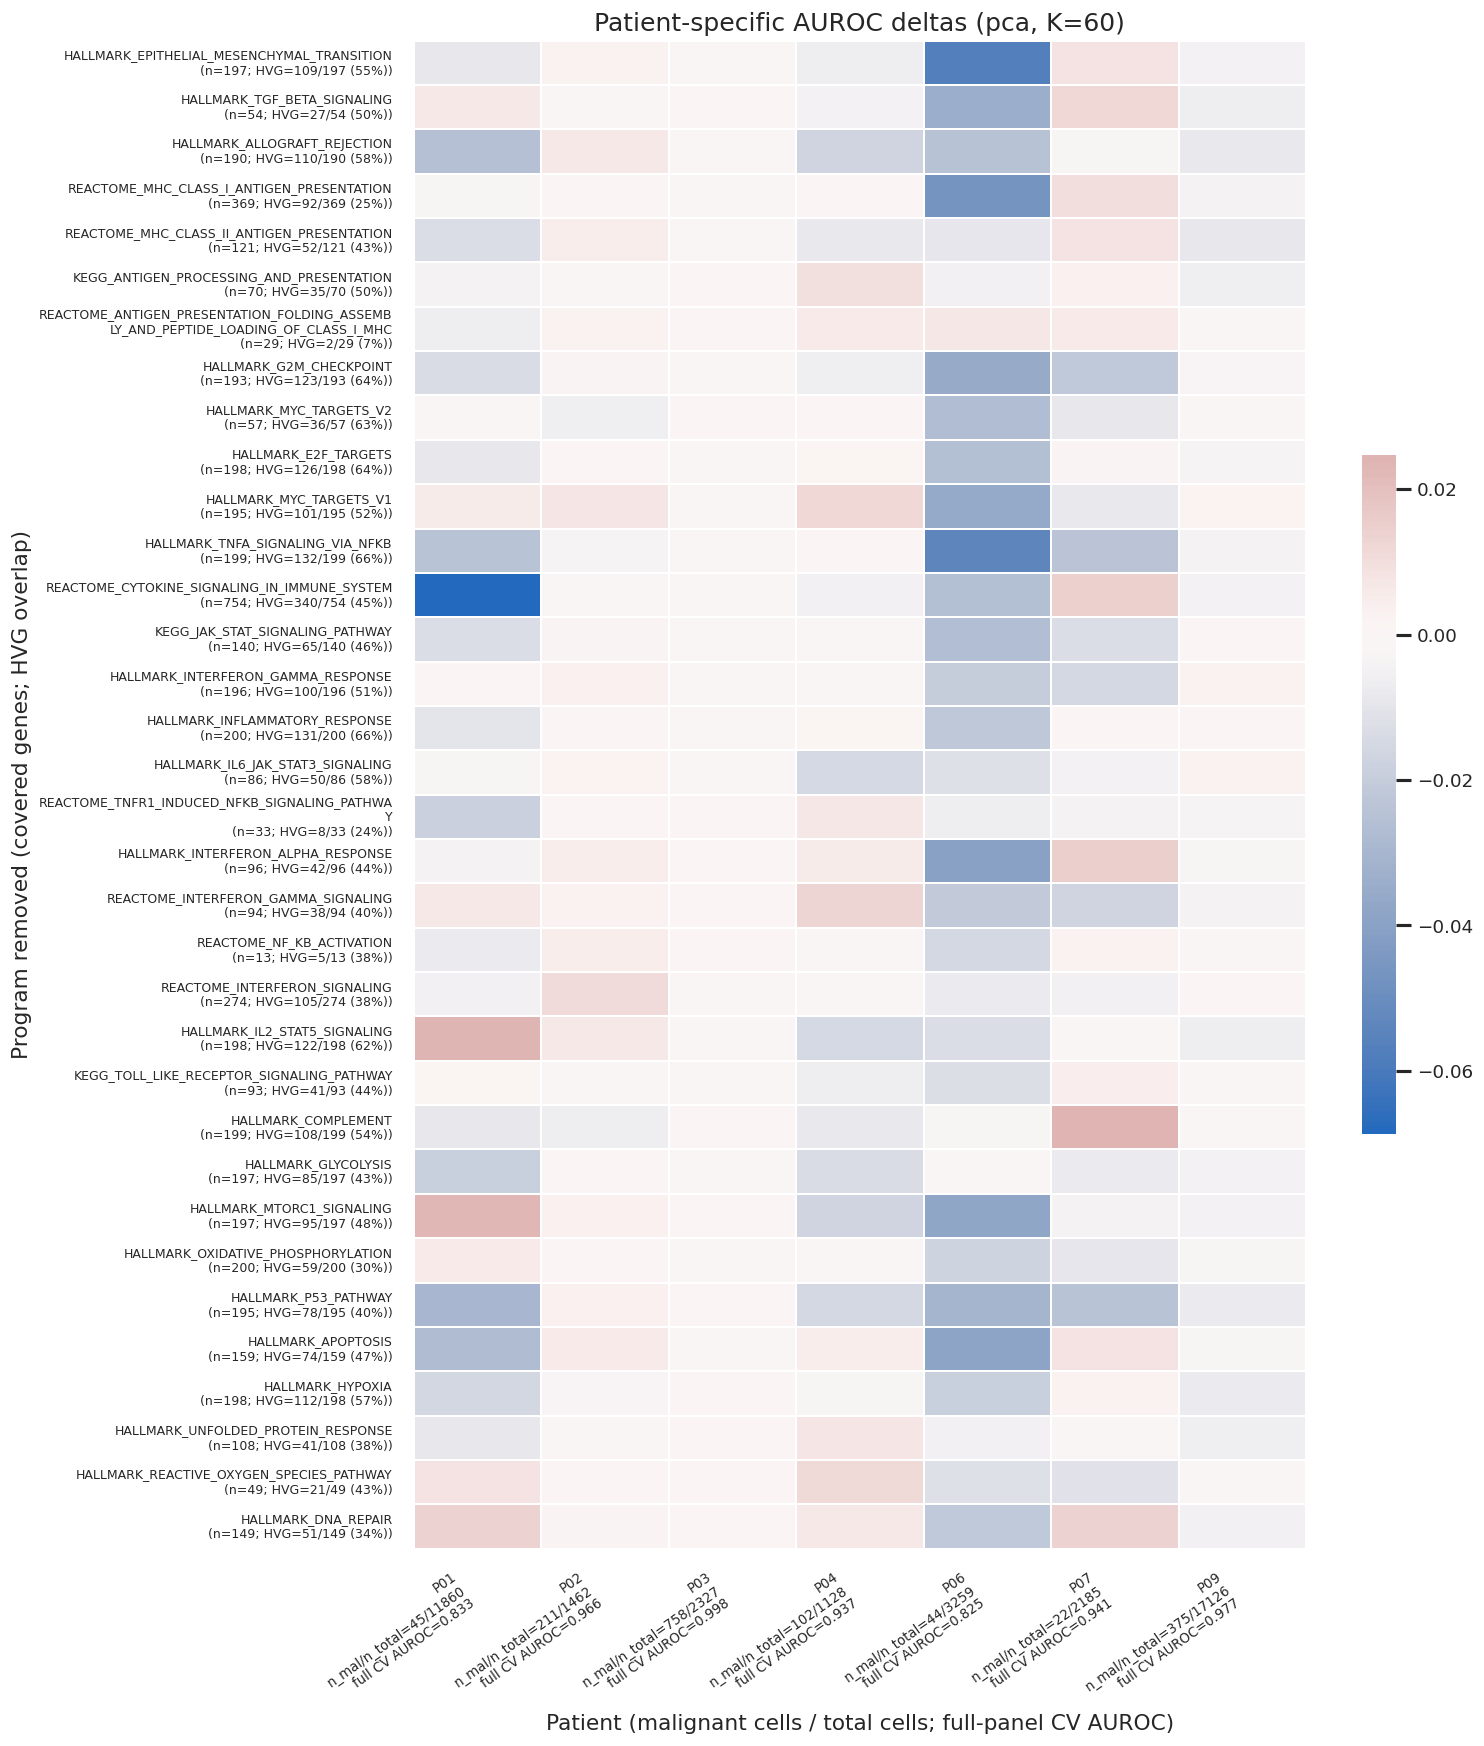

Saved figures/geneset_pruning_refined/11_patient_specific_theme_heatmap.png
Saved figures/geneset_pruning_refined/11_patient_specific_theme_heatmap.pdf


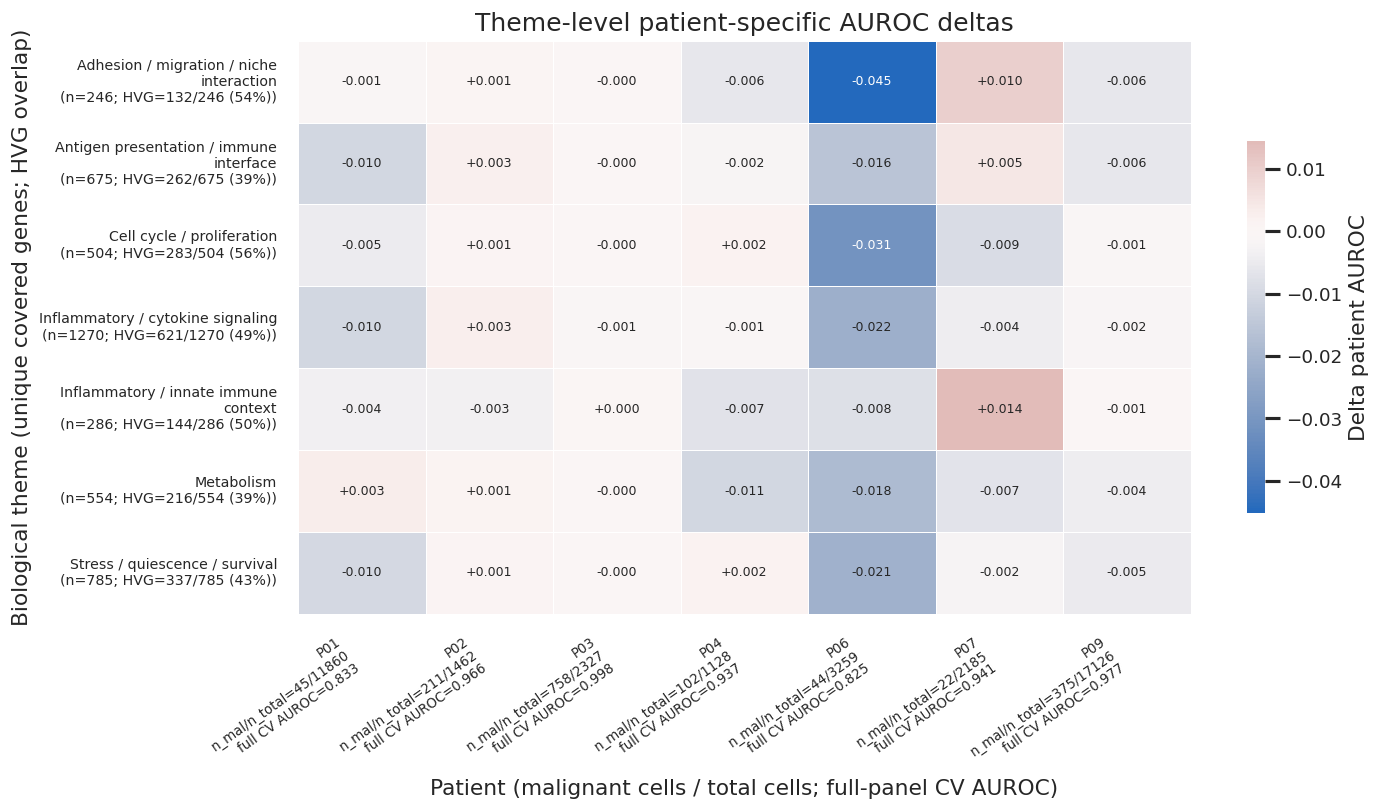

In [18]:
if PATIENT_DELTA_PATH.exists():
    patient_delta = pd.read_csv(PATIENT_DELTA_PATH)
    patient_delta = canonicalize_columns(patient_delta)
    if "K" not in patient_delta.columns and "k" in patient_delta.columns:
        patient_delta["K"] = pd.to_numeric(patient_delta["k"], errors="coerce").astype("Int64")
    if "panel" not in patient_delta.columns and "panel_id" in patient_delta.columns:
        patient_delta["panel"] = patient_delta["panel_id"]
    if "dropped_geneset" not in patient_delta.columns:
        patient_delta["dropped_geneset"] = patient_delta.apply(infer_dropped_geneset, axis=1)

    patient_primary = patient_delta.loc[
        patient_delta["method"].eq(PRIMARY_METHOD)
        & patient_delta["K"].eq(PRIMARY_K)
        & patient_delta["panel_type"].eq(LEAVE_ONE_PANEL_TYPE)
    ].copy()

    if patient_primary.empty:
        available_patient_settings = (
            patient_delta[["method", "K"]]
            .drop_duplicates()
            .sort_values(["method", "K"])
            .reset_index(drop=True)
        )
        display(Markdown(
            f"No patient-specific ablation table rows were found for `{PRIMARY_METHOD}`, `K={PRIMARY_K}`. "
            "Available patient-level settings are shown below."
        ))
        display(available_patient_settings)
    else:
        patient_primary = add_theme_column(patient_primary)
        patient_primary = add_geneset_count_labels(patient_primary, geneset_count_table)
        patient_primary = add_theme_count_labels(patient_primary, theme_count_table)
        full_cv_col = "full_34_patient_auroc" if "full_34_patient_auroc" in patient_delta.columns else "auroc"
        count_cols = ["n_malignant", "n_cells", full_cv_col]
        counts = (
            patient_delta.loc[patient_delta["panel"].eq(PANEL_FULL) & patient_delta["method"].eq(PRIMARY_METHOD) & patient_delta["K"].eq(PRIMARY_K)]
            .drop_duplicates("patient")
            .set_index("patient")[count_cols]
        )

        gene_order = (
            patient_primary.groupby(["theme", "dropped_geneset", "dropped_geneset_label"], as_index=False)["delta_patient_auroc"]
            .mean()
            .sort_values(["theme", "delta_patient_auroc"])
            ["dropped_geneset_label"]
            .tolist()
        )
        patient_order = sorted(patient_primary["patient"].unique())
        patient_labels = []
        for p in patient_order:
            if p in counts.index:
                n_mal = int(counts.loc[p, "n_malignant"])
                n_total = int(counts.loc[p, "n_cells"])
                full_cv = float(counts.loc[p, full_cv_col])
                patient_labels.append(f"{p}\nn_mal/n_total={n_mal}/{n_total}\nfull CV AUROC={full_cv:.3f}")
            else:
                patient_labels.append(str(p))

        patient_heat = patient_primary.pivot_table(
            index="dropped_geneset_label",
            columns="patient",
            values="delta_patient_auroc",
            aggfunc="mean",
        ).reindex(index=gene_order, columns=patient_order)

        fig, ax = plt.subplots(figsize=(max(12, 1.35 * len(patient_order)), max(10, 0.48 * len(patient_heat))))
        sns.heatmap(patient_heat, cmap="vlag", center=0, linewidths=0.2, ax=ax, cbar_kws={"shrink": 0.45})
        ax.set_xticklabels(patient_labels, rotation=35, ha="right", fontsize=8)
        ax.tick_params(axis="y", labelsize=7.5)
        ax.set_title(f"Patient-specific AUROC deltas ({PRIMARY_METHOD}, K={PRIMARY_K})")
        ax.set_xlabel("Patient (malignant cells / total cells; full-panel CV AUROC)")
        ax.set_ylabel("Program removed (covered genes; HVG overlap)")
        save_figure(fig, "10_patient_specific_geneset_heatmap")
        plt.show()

        theme_patient_heat = patient_primary.pivot_table(
            index="theme_label",
            columns="patient",
            values="delta_patient_auroc",
            aggfunc="mean",
        ).reindex(columns=patient_order)

        fig, ax = plt.subplots(figsize=(max(12, 1.35 * len(patient_order)), max(6.2, 0.8 * len(theme_patient_heat))))
        sns.heatmap(
            theme_patient_heat,
            cmap="vlag",
            center=0,
            annot=True,
            fmt="+.3f",
            annot_kws={"fontsize": 7.5},
            linewidths=0.5,
            linecolor="white",
            ax=ax,
            cbar_kws={"shrink": 0.65, "label": "Delta patient AUROC"},
        )
        ax.set_xticklabels(patient_labels, rotation=35, ha="right", fontsize=8)
        ax.tick_params(axis="y", labelsize=8.5)
        ax.set_title("Theme-level patient-specific AUROC deltas")
        ax.set_xlabel("Patient (malignant cells / total cells; full-panel CV AUROC)")
        ax.set_ylabel("Biological theme (unique covered genes; HVG overlap)")
        save_figure(fig, "11_patient_specific_theme_heatmap")
        plt.show()
else:
    display(Markdown(f"Patient-level ablation file is not available: `{PATIENT_DELTA_PATH}`"))

## 11. Final Summary

The final summary below is generated from the notebook variables so it updates when the selected setting or input tables change.

In [19]:
best_triage = full_select.sort_values("triage_score_refined", ascending=False).iloc[0]
best_malignancy = full_select.sort_values("malignancy_rank_score", ascending=False).iloc[0]
best_structure = full_select.sort_values("structure_rank_score", ascending=False).iloc[0]

most_damaging = (
    df_primary.sort_values("delta_triage_score")
    .head(5)[["dropped_geneset", "theme", "delta_triage_score", "delta_malignancy_rank_score", "delta_structure_rank_score"]]
)
strongest_themes = theme_summary.head(3)[["theme", "mean_delta_triage_score", "mean_delta_malignancy_rank_score", "mean_delta_structure_rank_score"]]

if "stability_summary" in globals() and not stability_summary.empty:
    stable_theme_text = ", ".join(stability_summary.head(3)["theme"].tolist())
else:
    stable_theme_text = "see sensitivity table"

summary_md = f"""
# Summary

1. **Full-panel hyperparameter behavior**
   - Best `full_34` setting by original/refined triage score: `{best_triage['method']}`, `K={int(best_triage['K'])}`.
   - Best setting by malignant-vs-normal generalization: `{best_malignancy['method']}`, `K={int(best_malignancy['K'])}`.
   - Best setting by structure preservation: `{best_structure['method']}`, `K={int(best_structure['K'])}`.
   - PCA may be advantaged in structure metrics if cell type/pseudotime were derived from PCA-like upstream workflows.

2. **Pruning interpretation**
   - Primary downstream setting: `{PRIMARY_METHOD}`, `K={PRIMARY_K}`.
   - Most damaging removals under the selected setting are listed below.
   - Effects should be interpreted through the sensitivity section before making gene-set-specific claims.

3. **Biological interpretation**
   - Current results support a distributed MRD program rather than a single dominant pathway.
   - Strongest affected themes under the selected setting are listed below.
   - This aligns with the manuscript claim of convergent but heterogeneous malignant MRD states involving inflammatory, stem-like, quiescent/stress, antigen-presentation, proliferation, and metabolic axes.

4. **Recommended figures for team meeting**
   - Full_34 malignancy vs structure scatter across method/K.
   - Full_34 heatmaps for malignancy and structure scores.
   - Selected-setting pruning scatter: delta structure vs delta malignancy.
   - Theme-level pruning summary.
   - Patient-specific heatmap only as backup/supplement.
"""

display(Markdown(summary_md))
print("Most damaging removals under selected setting:")
display(most_damaging)
print("Strongest affected themes under selected setting:")
display(strongest_themes)
print("Repeatedly damaging themes across selected settings:", stable_theme_text)

print("Notebook complete.")
print("Primary setting:", PRIMARY_METHOD, PRIMARY_K)
print("Figures saved to:", FIG_DIR)


# Summary

1. **Full-panel hyperparameter behavior**
   - Best `full_34` setting by original/refined triage score: `pca`, `K=60`.
   - Best setting by malignant-vs-normal generalization: `pca`, `K=60`.
   - Best setting by structure preservation: `pca`, `K=40`.
   - PCA may be advantaged in structure metrics if cell type/pseudotime were derived from PCA-like upstream workflows.

2. **Pruning interpretation**
   - Primary downstream setting: `pca`, `K=60`.
   - Most damaging removals under the selected setting are listed below.
   - Effects should be interpreted through the sensitivity section before making gene-set-specific claims.

3. **Biological interpretation**
   - Current results support a distributed MRD program rather than a single dominant pathway.
   - Strongest affected themes under the selected setting are listed below.
   - This aligns with the manuscript claim of convergent but heterogeneous malignant MRD states involving inflammatory, stem-like, quiescent/stress, antigen-presentation, proliferation, and metabolic axes.

4. **Recommended figures for team meeting**
   - Full_34 malignancy vs structure scatter across method/K.
   - Full_34 heatmaps for malignancy and structure scores.
   - Selected-setting pruning scatter: delta structure vs delta malignancy.
   - Theme-level pruning summary.
   - Patient-specific heatmap only as backup/supplement.


Most damaging removals under selected setting:


,dropped_geneset,theme,delta_triage_score,delta_malignancy_rank_score,delta_structure_rank_score
33,REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM,Inflammatory / cytokine signaling,-0.316658,-0.169192,-0.534091
32,HALLMARK_HYPOXIA,Stress / quiescence / survival,-0.290056,-0.434343,-0.164141
31,HALLMARK_ALLOGRAFT_REJECTION,Antigen presentation / immune interface,-0.275907,-0.321970,-0.247475
30,HALLMARK_TGF_BETA_SIGNALING,Adhesion / migration / niche interaction,-0.274010,-0.489899,-0.063131
29,HALLMARK_P53_PATHWAY,Stress / quiescence / survival,-0.268730,-0.410354,-0.145202


Strongest affected themes under selected setting:


,theme,mean_delta_triage_score,mean_delta_malignancy_rank_score,mean_delta_structure_rank_score
4,Inflammatory / innate immune context,-0.203769,-0.289773,-0.131313
1,Antigen presentation / immune interface,-0.186332,-0.273232,-0.113889
6,Stress / quiescence / survival,-0.183285,-0.272096,-0.107744


Repeatedly damaging themes across selected settings: Inflammatory / innate immune context, Inflammatory / cytokine signaling, Adhesion / migration / niche interaction
Notebook complete.
Primary setting: pca 60
Figures saved to: figures/geneset_pruning_refined
